# 🩺 Preprocessing: Diabetes Health Indicators Dataset (BRFSS 2015)

**Dataset:** `diabetes_012_health_indicators_BRFSS2015.csv`  
**Source:** [Kaggle - Alex Teboul](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

---

### 📋 Alur Preprocessing:

1. Load & Inspeksi Awal
2. Pemahaman Fitur (Data Dictionary)
3. Pengecekan Missing Values
4. Pengecekan Duplikat
5. Analisis Distribusi & Outlier
6. Penanganan Outlier
7. Encoding Fitur Kategorikal
8. Feature Scaling / Normalisasi
9. Penanganan Class Imbalance
10. Feature Selection
11. Split Data (Train/Val/Test)
12. Simpan Data Hasil Preprocessing


## 0️⃣ Install & Import Library


In [ ]:
# Install library tambahan jika belum ada
pip install imbalanced-learn -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 📂 Upload / Mount Dataset

> **Pilih salah satu cara** load data di bawah ini (uncomment yang sesuai).


In [29]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

ModuleNotFoundError: No module named 'google'

In [2]:
df = pd.read_csv("/media/fatih/Data/KULIAH/KULIAH/sains-data/smt4/kda/PROJEK/kda-projek-kelompok-2/data/raw/diabetes__health_indicators.csv")

---

## 1️⃣ Inspeksi Awal Dataset


In [3]:
print('=' * 60)
print(f'SHAPE     : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print('=' * 60)
df.head()

SHAPE     : 253,680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0000,1.0000,1.0000,1.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,5.0000,18.0000,15.0000,1.0000,0.0000,9.0000,4.0000,3.0000
1,0.0000,0.0000,0.0000,0.0000,25.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,0.0000,0.0000,0.0000,0.0000,7.0000,6.0000,1.0000
2,0.0000,1.0000,1.0000,1.0000,28.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,0.0000,9.0000,4.0000,8.0000
3,0.0000,1.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,11.0000,3.0000,6.0000
4,0.0000,1.0000,1.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,3.0000,0.0000,0.0000,0.0000,11.0000,5.0000,4.0000


In [4]:
print('Tipe Data & Non-Null Count:')
df.info()

Tipe Data & Non-Null Count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               25

In [5]:
print('Statistik Deskriptif:')
df.describe().T

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0000,0.2969,0.6982,0.0000,0.0000,0.0000,0.0000,2.0000
HighBP,253680.0000,0.4290,0.4949,0.0000,0.0000,0.0000,1.0000,1.0000
HighChol,253680.0000,0.4241,0.4942,0.0000,0.0000,0.0000,1.0000,1.0000
CholCheck,253680.0000,0.9627,0.1896,0.0000,1.0000,1.0000,1.0000,1.0000
BMI,253680.0000,28.3824,6.6087,12.0000,24.0000,27.0000,31.0000,98.0000
Smoker,253680.0000,0.4432,0.4968,0.0000,0.0000,0.0000,1.0000,1.0000
Stroke,253680.0000,0.0406,0.1973,0.0000,0.0000,0.0000,0.0000,1.0000
HeartDiseaseorAttack,253680.0000,0.0942,0.2921,0.0000,0.0000,0.0000,0.0000,1.0000
PhysActivity,253680.0000,0.7565,0.4292,0.0000,1.0000,1.0000,1.0000,1.0000
Fruits,253680.0000,0.6343,0.4816,0.0000,0.0000,1.0000,1.0000,1.0000


---

## 2️⃣ Data Dictionary & Tipe Fitur

Klasifikasi fitur berdasarkan jenisnya:


In [6]:
data_dict = {
    'Kolom': [
        'Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
        'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
        'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth',
        'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
    ],
    'Deskripsi': [
        'Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes',
        'Tekanan darah tinggi (0=Tidak, 1=Ya)',
        'Kolesterol tinggi (0=Tidak, 1=Ya)',
        'Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)',
        'Body Mass Index (numerik kontinu)',
        'Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)',
        'Pernah stroke (0=Tidak, 1=Ya)',
        'Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)',
        'Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)',
        'Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi sayur ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi alkohol berat (0=Tidak, 1=Ya)',
        'Memiliki asuransi kesehatan (0=Tidak, 1=Ya)',
        'Tidak periksa dokter karena biaya (0=Tidak, 1=Ya)',
        'Kesehatan umum: 1=Sangat Baik s.d. 5=Buruk (ordinal)',
        'Hari kesehatan mental buruk (0-30 hari)',
        'Hari kesehatan fisik buruk (0-30 hari)',
        'Kesulitan berjalan/naik tangga (0=Tidak, 1=Ya)',
        'Jenis kelamin (0=Perempuan, 1=Laki-laki)',
        'Kelompok usia (1=18-24 s.d. 13=80+) ordinal',
        'Tingkat pendidikan (1-6) ordinal',
        'Tingkat pendapatan (1-8) ordinal'
    ],
    'Tipe': [
        'Target (Multiclass)', 'Biner', 'Biner', 'Biner', 'Kontinu',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Ordinal', 'Kontinu', 'Kontinu',
        'Biner', 'Biner', 'Ordinal', 'Ordinal', 'Ordinal'
    ]
}

dict_df = pd.DataFrame(data_dict)
print('Data Dictionary:')
dict_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}]
)

Data Dictionary:


,Kolom,Deskripsi,Tipe
0,Diabetes_012,"Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes",Target (Multiclass)
1,HighBP,"Tekanan darah tinggi (0=Tidak, 1=Ya)",Biner
2,HighChol,"Kolesterol tinggi (0=Tidak, 1=Ya)",Biner
3,CholCheck,"Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)",Biner
4,BMI,Body Mass Index (numerik kontinu),Kontinu
5,Smoker,"Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)",Biner
6,Stroke,"Pernah stroke (0=Tidak, 1=Ya)",Biner
7,HeartDiseaseorAttack,"Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)",Biner
8,PhysActivity,"Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)",Biner
9,Fruits,"Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)",Biner


In [7]:
TARGET = 'Diabetes_012'

BINARY_FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

ORDINAL_FEATURES = ['GenHlth', 'Age', 'Education', 'Income']

CONTINUOUS_FEATURES = ['BMI', 'MentHlth', 'PhysHlth']

print(f'Target       : {TARGET}')
print(f'Biner        : {len(BINARY_FEATURES)} fitur → {BINARY_FEATURES}')
print(f'Ordinal      : {len(ORDINAL_FEATURES)} fitur → {ORDINAL_FEATURES}')
print(f'Kontinu      : {len(CONTINUOUS_FEATURES)} fitur → {CONTINUOUS_FEATURES}')

Target       : Diabetes_012
Biner        : 14 fitur → ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal      : 4 fitur → ['GenHlth', 'Age', 'Education', 'Income']
Kontinu      : 3 fitur → ['BMI', 'MentHlth', 'PhysHlth']


---

## 3️⃣ Pengecekan Missing Values


In [8]:
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

if missing['Jumlah Missing'].sum() == 0:
    print('Tidak ada missing values dalam dataset ini!')
else:
    print('Kolom dengan missing values:')
    print(missing[missing['Jumlah Missing'] > 0])

    plt.figure(figsize=(10, 4))
    missing[missing['Jumlah Missing'] > 0]['Persentase (%)'].plot(kind='bar', color='tomato')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.tight_layout()
    plt.show()

missing

Tidak ada missing values dalam dataset ini!


,Jumlah Missing,Persentase (%)
Diabetes_012,0,0.0000
HighBP,0,0.0000
HighChol,0,0.0000
CholCheck,0,0.0000
BMI,0,0.0000
Smoker,0,0.0000
Stroke,0,0.0000
HeartDiseaseorAttack,0,0.0000
PhysActivity,0,0.0000
Fruits,0,0.0000


---

## 4️⃣ Pengecekan & Penghapusan Duplikat


In [9]:
n_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_duplikat:,}')
print(f'   Persentase           : {n_duplikat/len(df)*100:.2f}%')

if n_duplikat > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplikat dihapus. Shape baru: {df.shape}')
else:
    print('Tidak ada duplikat ditemukan.')

Jumlah baris duplikat: 23,899
   Persentase           : 9.42%
Duplikat dihapus. Shape baru: (229781, 22)


---

## 5️⃣ Analisis Distribusi & Target


Distribusi Kelas Target (Diabetes_012):
                    Label  Jumlah  Persentase %
Diabetes_012                                   
0.0000        No Diabetes  190055       82.7100
1.0000        Prediabetes    4629        2.0100
2.0000           Diabetes   35097       15.2700


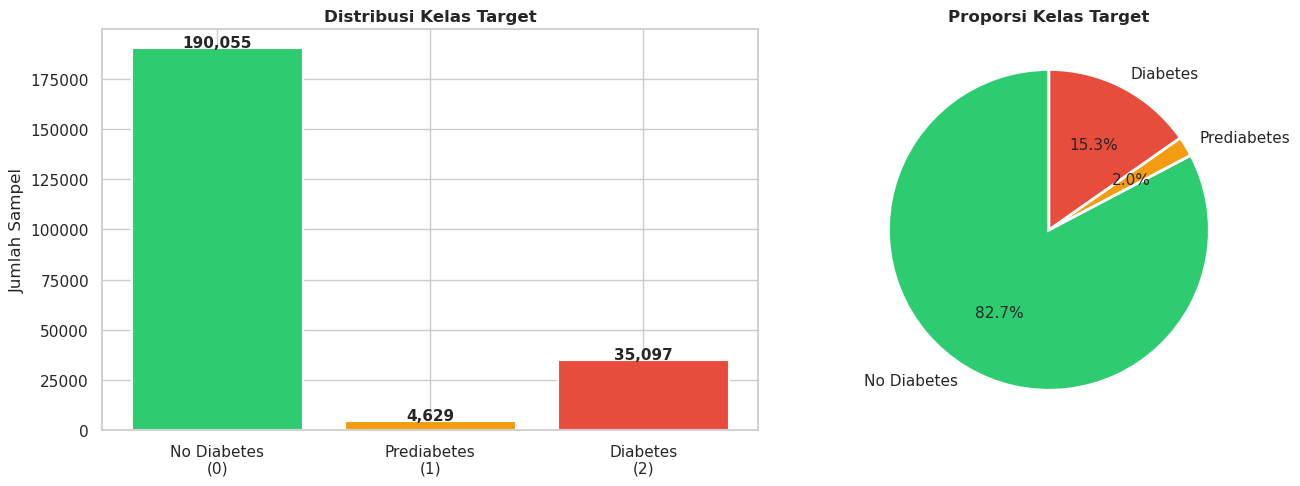

In [10]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct    = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Label'       : ['No Diabetes', 'Prediabetes', 'Diabetes'],
    'Jumlah'      : target_counts.values,
    'Persentase %': target_pct.values.round(2)
}, index=target_counts.index)

print('Distribusi Kelas Target (Diabetes_012):')
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(['No Diabetes\n(0)', 'Prediabetes\n(1)', 'Diabetes\n(2)'],
            target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

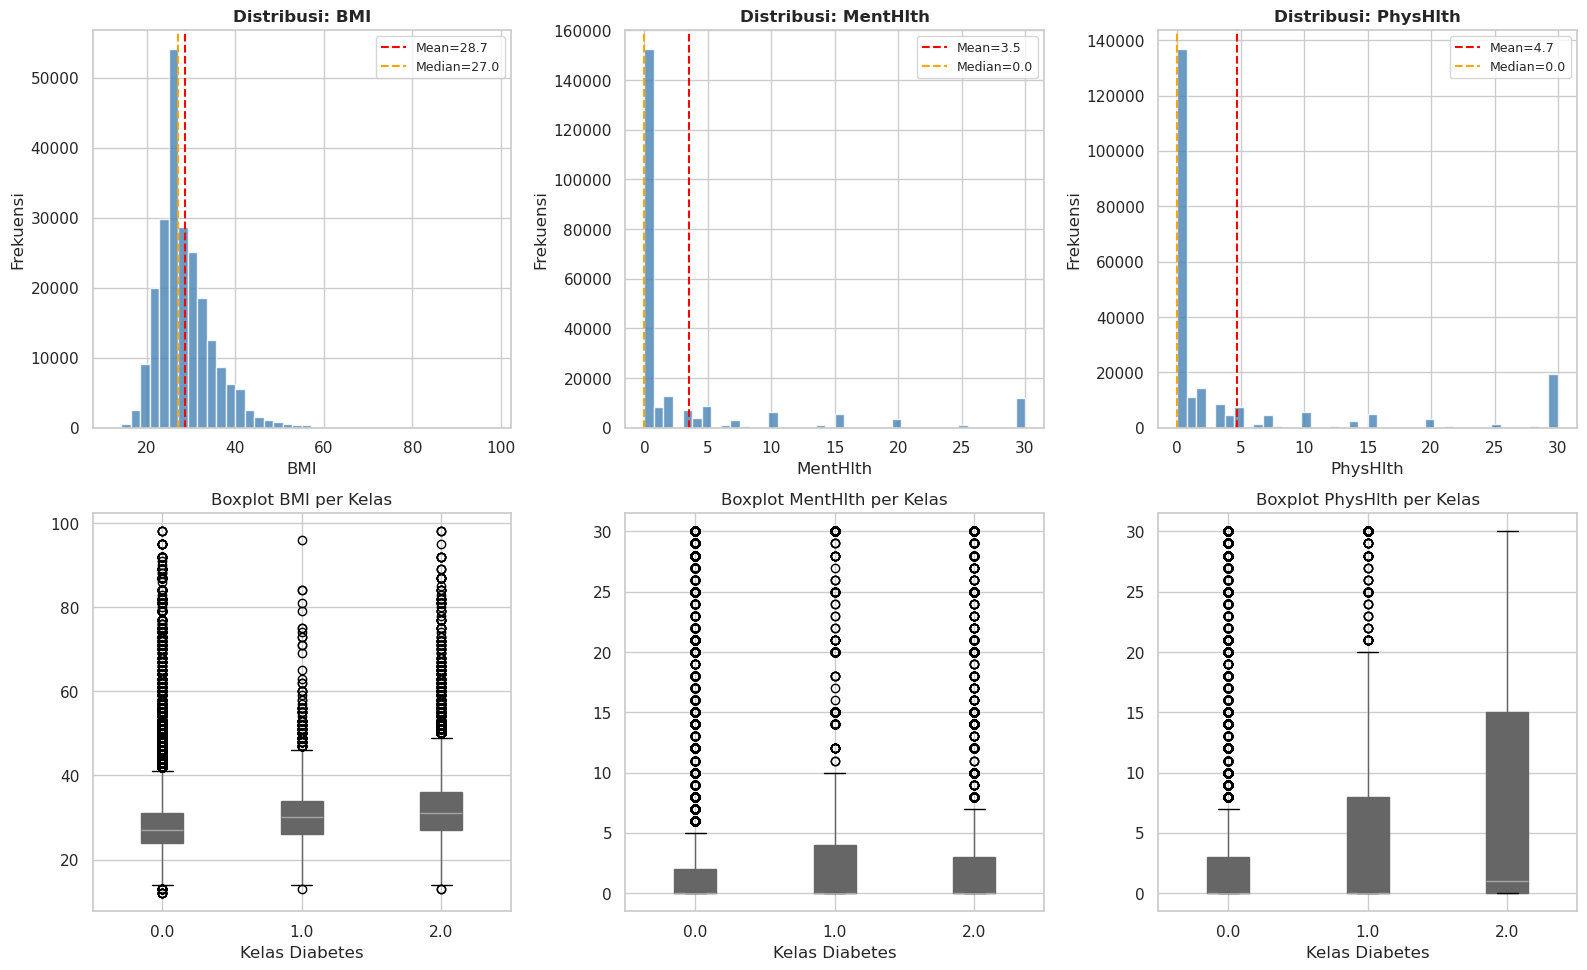

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_FEATURES):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=9)

for j, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[3 + j]
    df.boxplot(column=col, by=TARGET, ax=ax, patch_artist=True)
    ax.set_title(f'Boxplot {col} per Kelas', fontweight='bold')
    ax.set_xlabel('Kelas Diabetes')
    plt.sca(ax)
    plt.title(f'Boxplot {col} per Kelas')

plt.suptitle('')
plt.tight_layout()
plt.show()

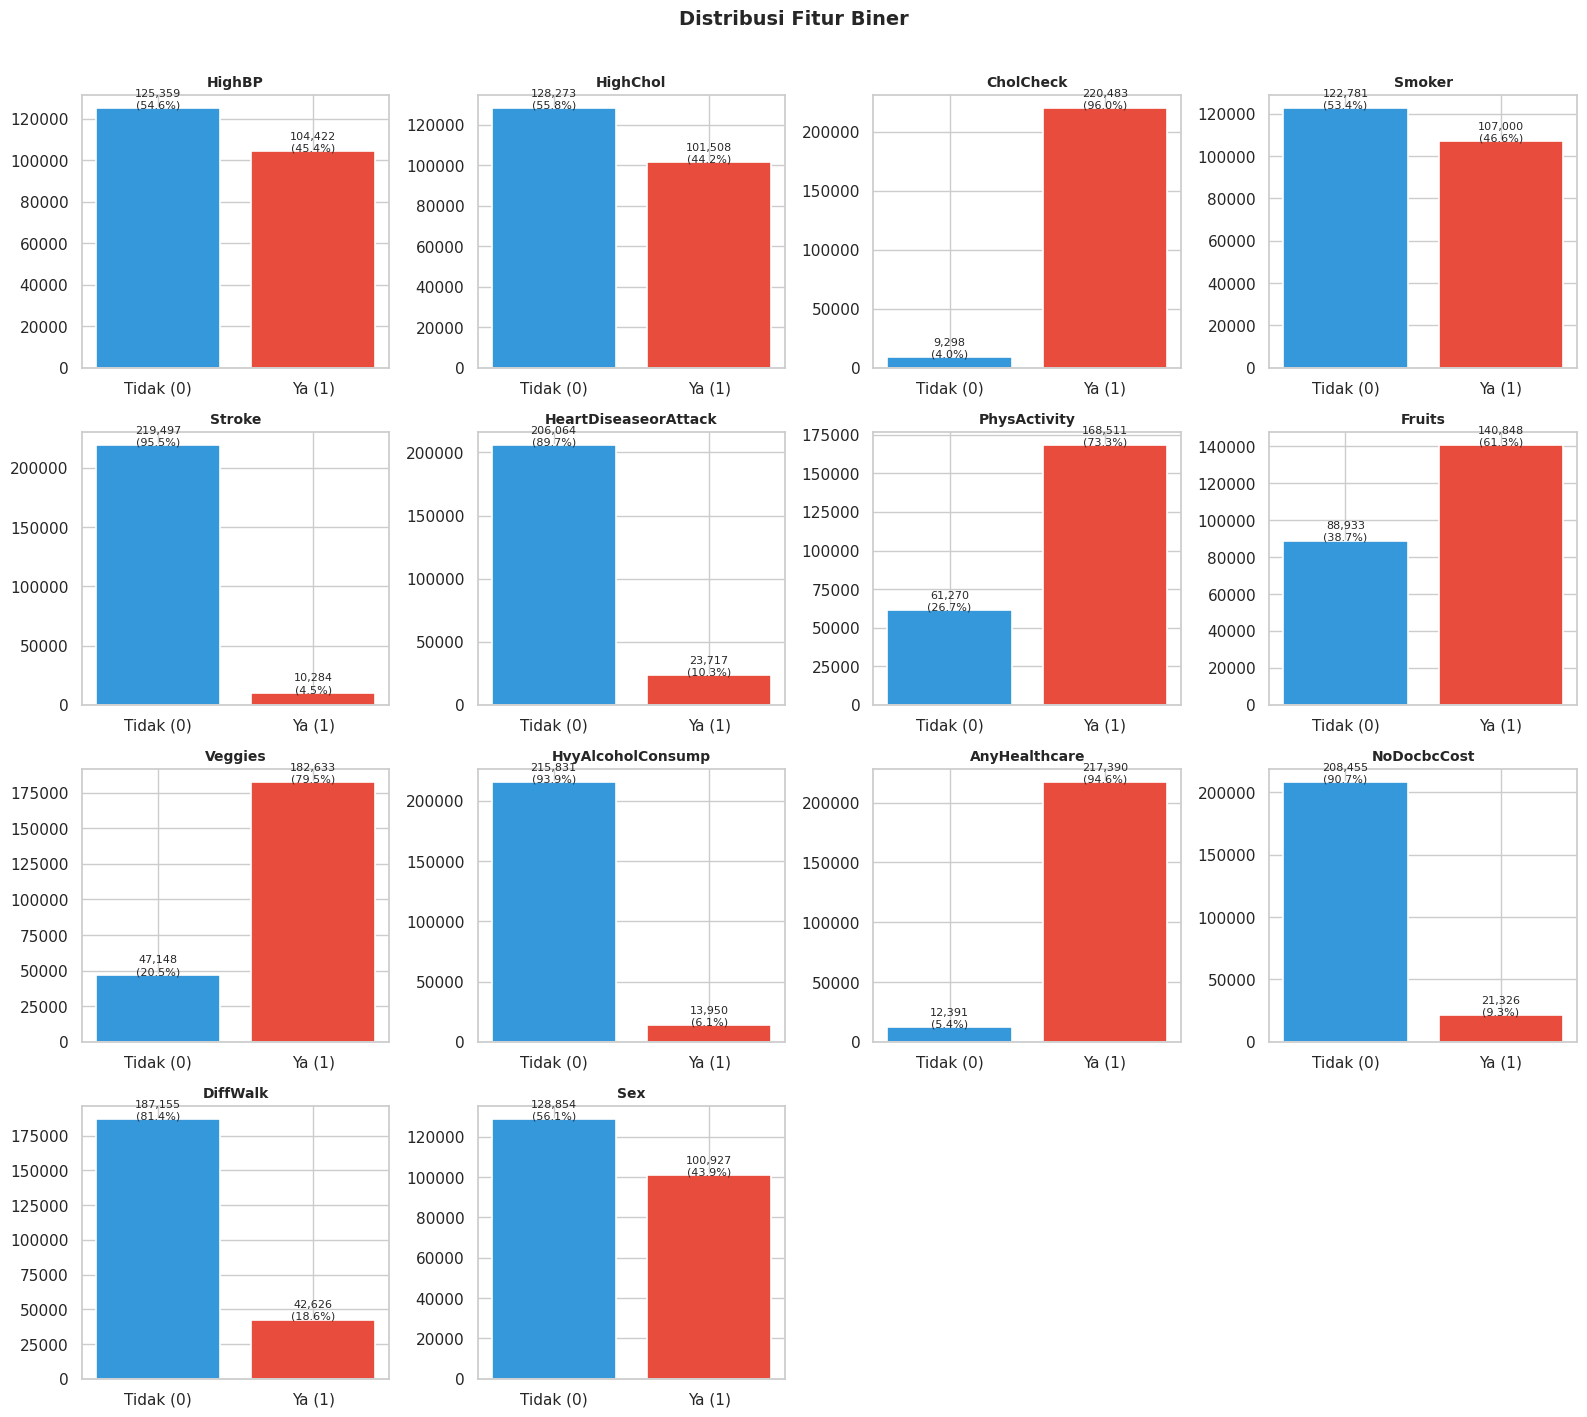

In [12]:
n_cols = 4
n_rows = (len(BINARY_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(BINARY_FEATURES):
    val_counts = df[col].value_counts().sort_index()
    axes[i].bar(['Tidak (0)', 'Ya (1)'], val_counts.values,
                color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    for k, v in enumerate(val_counts.values):
        axes[i].text(k, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Biner', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 6️⃣ Deteksi & Penanganan Outlier (Fitur Kontinu)


In [13]:
def detect_outliers_iqr(df, columns):
    """Deteksi outlier menggunakan metode IQR"""
    results = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'Fitur'       : col,
            'Q1'          : round(Q1, 2),
            'Q3'          : round(Q3, 2),
            'IQR'         : round(IQR, 2),
            'Batas Bawah' : round(lower, 2),
            'Batas Atas'  : round(upper, 2),
            'Jml Outlier' : n_out,
            'Pct Outlier%': round(n_out / len(df) * 100, 2)
        })
    return pd.DataFrame(results)

outlier_report = detect_outliers_iqr(df, CONTINUOUS_FEATURES)
print('Laporan Outlier (Metode IQR):')
outlier_report

Laporan Outlier (Metode IQR):


,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jml Outlier,Pct Outlier%
0,BMI,24.0000,32.0000,8.0000,12.0000,44.0000,5638,2.4500
1,MentHlth,0.0000,2.0000,2.0000,-3.0000,5.0000,36163,15.7400
2,PhysHlth,0.0000,4.0000,4.0000,-6.0000,10.0000,34347,14.9500


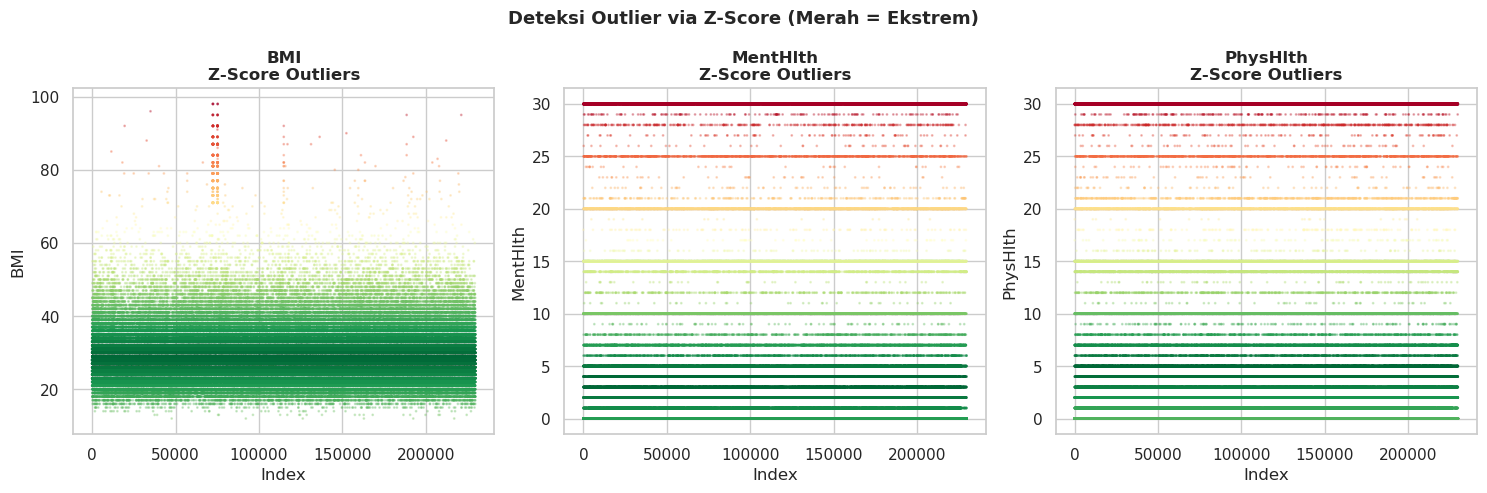

In [14]:
fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(15, 5))

for i, col in enumerate(CONTINUOUS_FEATURES):
    z_scores = np.abs(stats.zscore(df[col]))
    axes[i].scatter(range(len(df)), df[col], c=z_scores, cmap='RdYlGn_r',
                    alpha=0.3, s=1)
    axes[i].set_title(f'{col}\nZ-Score Outliers', fontweight='bold')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier via Z-Score (Merah = Ekstrem)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
OUTLIER_FEATURES = ['BMI']

df_clean = df.copy()

for col in OUTLIER_FEATURES:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # clipping / winsorizing
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f' {col}: clipping ke [{lower:.2f}, {upper:.2f}]')

print(f'\nShape setelah capping: {df_clean.shape}')

 BMI: clipping ke [12.00, 44.00]

Shape setelah capping: (229781, 22)


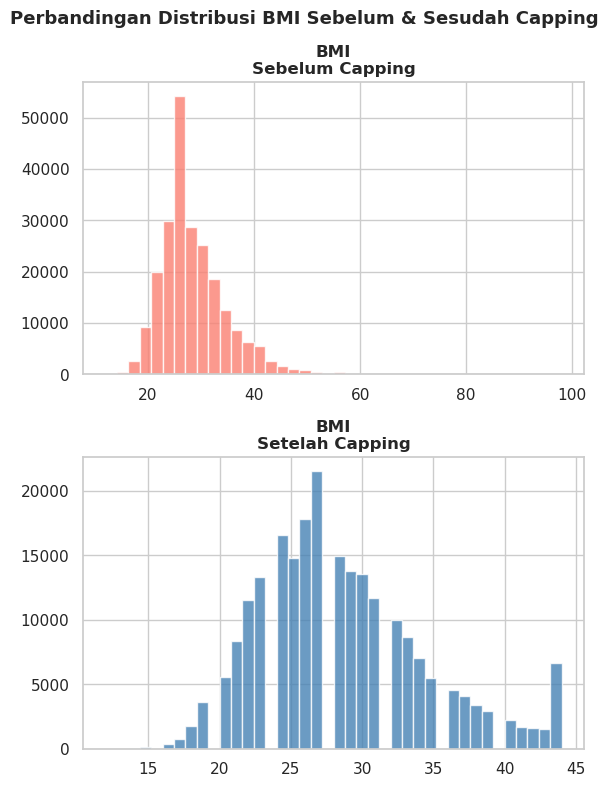

In [16]:
fig, axes = plt.subplots(2, len(OUTLIER_FEATURES), figsize=(6, 8))

if len(OUTLIER_FEATURES) == 1:
    axes = np.array(axes).reshape(2,1)

for i, col in enumerate(OUTLIER_FEATURES):

    axes[0, i].hist(
        df[col],
        bins=40,
        color='salmon',
        edgecolor='white',
        alpha=0.8
    )
    axes[0, i].set_title(
        f'{col}\nSebelum Capping',
        fontweight='bold'
    )

    axes[1, i].hist(
        df_clean[col],
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.8
    )
    axes[1, i].set_title(
        f'{col}\nSetelah Capping',
        fontweight='bold'
    )

plt.suptitle(
    'Perbandingan Distribusi BMI Sebelum & Sesudah Capping',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---

## 7️⃣ Encoding Fitur Kategorikal

Dataset ini sudah dalam bentuk numerik, namun kita perlu memastikan tipe data sudah benar.


In [17]:
for col in BINARY_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

for col in ORDINAL_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

df_clean[TARGET] = df_clean[TARGET].astype('int8')

print(' Tipe data setelah konversi:')
print(df_clean.dtypes)
print(f'\n Penggunaan memori: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

 Tipe data setelah konversi:
Diabetes_012               int8
HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float64
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                    int8
MentHlth                float64
PhysHlth                float64
DiffWalk                   int8
Sex                        int8
Age                        int8
Education                  int8
Income                     int8
dtype: object

 Penggunaan memori: 9.42 MB


In [18]:
df_privacy = df_clean.copy()

df_ml = df_clean.copy()

print('Dataset dipisah:')
print(f'   df_privacy : {df_privacy.shape}')
print(f'   df_ml      : {df_ml.shape}')

Dataset dipisah:
   df_privacy : (229781, 22)
   df_ml      : (229781, 22)


---

## 9️⃣ Attribute Role Definition


In [19]:
IDENTIFIER_ATTRIBUTES = []

QI_ATTRIBUTES = [
    'Age',
    'Sex',
    'Education',
    'Income',
    'BMI',
    'GenHlth'
]

SENSITIVE_ATTRIBUTE = 'Diabetes_012'

SENSITIVE_CANDIDATES = [
    'Diabetes_012',
    'HighBP',
    'HighChol',
    'HeartDiseaseorAttack',
    'Stroke'
]

NON_SENSITIVE_ATTRIBUTES = [
    'Smoker',
    'HvyAlcoholConsump',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'CholCheck',
    'AnyHealthcare',
    'NoDocbcCost'
]

print('Identifier Attributes:', IDENTIFIER_ATTRIBUTES)
print('Quasi-Identifier Attributes:', QI_ATTRIBUTES)
print('Sensitive Attribute:', SENSITIVE_ATTRIBUTE)
print('Non-Sensitive Attributes:', NON_SENSITIVE_ATTRIBUTES)

Identifier Attributes: []
Quasi-Identifier Attributes: ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
Sensitive Attribute: Diabetes_012
Non-Sensitive Attributes: ['Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'Fruits', 'Veggies', 'MentHlth', 'PhysHlth', 'DiffWalk', 'CholCheck', 'AnyHealthcare', 'NoDocbcCost']


---

## 🔟 Generalization


In [20]:
# ================================
# CONFIGURATION & CONSTANTS
# ================================

# Privacy parameters
K_ANONYMITY = 5          # Minimum group size
EPSILON = 1.0            # Privacy budget
MAX_LEVEL = 3            # Maximum generalization level (0-3)

# QI Attributes (already defined, but reconfirm)
QI_ATTRIBUTES = [
    'Age',
    'Sex',
    'Education',
    'Income',
    'BMI',
    'GenHlth'
]

SENSITIVE_ATTRIBUTE = 'Diabetes_012'

print('='*60)
print('PRIVACY CONFIGURATION')
print('='*60)
print(f'K-Anonymity       : {K_ANONYMITY}')
print(f'Privacy Budget (ε): {EPSILON}')
print(f'Max Level         : {MAX_LEVEL}')
print(f'QI Attributes     : {QI_ATTRIBUTES}')
print(f'Sensitive Attr    : {SENSITIVE_ATTRIBUTE}')
print('='*60)

PRIVACY CONFIGURATION
K-Anonymity       : 5
Privacy Budget (ε): 1.0
Max Level         : 3
QI Attributes     : ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
Sensitive Attr    : Diabetes_012


In [21]:
# ================================
# AGE MULTI-LEVEL GENERALIZATION
# ================================

def generalize_age(value, level):
    """
    Age Multi-Level Hierarchy
    
    Original values: 1-13 (age groups)
    Level 0: Original (1, 2, 3, ..., 13)
    Level 1: Young (1-3), Adult (4-7), MiddleAge (8-10), Senior (11-13)
    Level 2: Young-Adult (1-7), Senior (8-13)
    Level 3: Any
    
    Args:
        value (int): Original age value (1-13)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized age value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 4 categories
        if value <= 3:
            return 'Young'
        elif value <= 7:
            return 'Adult'
        elif value <= 10:
            return 'MiddleAge'
        else:
            return 'Senior'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 7:
            return 'Young-Adult'
        else:
            return 'Senior'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Age Generalization
print('AGE GENERALIZATION TEST:')
print('='*60)
test_ages = [1, 5, 9, 13]
for age in test_ages:
    print(f'Age={age:2d} → L0:{generalize_age(age, 0):2} | '
          f'L1:{generalize_age(age, 1):10s} | '
          f'L2:{generalize_age(age, 2):12s} | '
          f'L3:{generalize_age(age, 3)}')
print('='*60)

AGE GENERALIZATION TEST:
Age= 1 → L0: 1 | L1:Young      | L2:Young-Adult  | L3:Any
Age= 5 → L0: 5 | L1:Adult      | L2:Young-Adult  | L3:Any
Age= 9 → L0: 9 | L1:MiddleAge  | L2:Senior       | L3:Any
Age=13 → L0:13 | L1:Senior     | L2:Senior       | L3:Any


In [22]:
# ================================
# BMI MULTI-LEVEL GENERALIZATION
# ================================

def generalize_bmi(value, level):
    """
    BMI Multi-Level Hierarchy
    
    Original values: 12-98 (continuous BMI)
    Level 0: Original value
    Level 1: Underweight (<18.5), Normal (18.5-25), Overweight (25-30), Obese (30+)
    Level 2: Normal-Range (<25), Overweight-Range (25+)
    Level 3: Any
    
    Args:
        value (float): Original BMI value
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized BMI value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 4 categories (WHO classification)
        if value < 18.5:
            return 'Underweight'
        elif value < 25:
            return 'Normal'
        elif value < 30:
            return 'Overweight'
        else:
            return 'Obese'
    
    elif level == 2:
        # Level 2: 2 categories
        if value < 25:
            return 'Normal-Range'
        else:
            return 'Overweight-Range'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test BMI Generalization
print('BMI GENERALIZATION TEST:')
print('='*60)
test_bmis = [17.0, 22.5, 28.0, 35.0]
for bmi in test_bmis:
    print(f'BMI={bmi:4.1f} → L0:{generalize_bmi(bmi, 0):4.1f} | '
          f'L1:{generalize_bmi(bmi, 1):12s} | '
          f'L2:{generalize_bmi(bmi, 2):18s} | '
          f'L3:{generalize_bmi(bmi, 3)}')
print('='*60)

BMI GENERALIZATION TEST:
BMI=17.0 → L0:17.0 | L1:Underweight  | L2:Normal-Range       | L3:Any
BMI=22.5 → L0:22.5 | L1:Normal       | L2:Normal-Range       | L3:Any
BMI=28.0 → L0:28.0 | L1:Overweight   | L2:Overweight-Range   | L3:Any
BMI=35.0 → L0:35.0 | L1:Obese        | L2:Overweight-Range   | L3:Any


In [23]:
# ================================
# INCOME MULTI-LEVEL GENERALIZATION
# ================================

def generalize_income(value, level):
    """
    Income Multi-Level Hierarchy
    
    Original values: 1-8 (income brackets)
    1: <$10k, 2: $10-15k, 3: $15-20k, 4: $20-25k,
    5: $25-35k, 6: $35-50k, 7: $50-75k, 8: $75k+
    
    Level 0: Original (1-8)
    Level 1: Low (1-3), Middle (4-6), High (7-8)
    Level 2: Low-Middle (1-6), High (7-8)
    Level 3: Any
    
    Args:
        value (int): Original income value (1-8)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized income value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 3:
            return 'Low'
        elif value <= 6:
            return 'Middle'
        else:
            return 'High'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 6:
            return 'Low-Middle'
        else:
            return 'High'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Income Generalization
print('INCOME GENERALIZATION TEST:')
print('='*60)
test_incomes = [1, 4, 6, 8]
for inc in test_incomes:
    print(f'Income={inc} → L0:{generalize_income(inc, 0)} | '
          f'L1:{generalize_income(inc, 1):10s} | '
          f'L2:{generalize_income(inc, 2):10s} | '
          f'L3:{generalize_income(inc, 3)}')
print('='*60)

INCOME GENERALIZATION TEST:
Income=1 → L0:1 | L1:Low        | L2:Low-Middle | L3:Any
Income=4 → L0:4 | L1:Middle     | L2:Low-Middle | L3:Any
Income=6 → L0:6 | L1:Middle     | L2:Low-Middle | L3:Any
Income=8 → L0:8 | L1:High       | L2:High       | L3:Any


In [24]:
# ================================
# EDUCATION MULTI-LEVEL GENERALIZATION
# ================================

def generalize_education(value, level):
    """
    Education Multi-Level Hierarchy
    
    Original values: 1-6 (education levels)
    1: Never attended, 2: Elementary, 3: Some HS,
    4: HS Graduate, 5: Some College, 6: College Graduate
    
    Level 0: Original (1-6)
    Level 1: LowEdu (1-2), MidEdu (3-4), HighEdu (5-6)
    Level 2: LowEdu (1-4), HighEdu (5-6)
    Level 3: Any
    
    Args:
        value (int): Original education value (1-6)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized education value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 2:
            return 'LowEdu'
        elif value <= 4:
            return 'MidEdu'
        else:
            return 'HighEdu'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 4:
            return 'LowEdu'
        else:
            return 'HighEdu'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Education Generalization
print('EDUCATION GENERALIZATION TEST:')
print('='*60)
test_edus = [1, 3, 5, 6]
for edu in test_edus:
    print(f'Education={edu} → L0:{generalize_education(edu, 0)} | '
          f'L1:{generalize_education(edu, 1):7s} | '
          f'L2:{generalize_education(edu, 2):7s} | '
          f'L3:{generalize_education(edu, 3)}')
print('='*60)

EDUCATION GENERALIZATION TEST:
Education=1 → L0:1 | L1:LowEdu  | L2:LowEdu  | L3:Any
Education=3 → L0:3 | L1:MidEdu  | L2:LowEdu  | L3:Any
Education=5 → L0:5 | L1:HighEdu | L2:HighEdu | L3:Any
Education=6 → L0:6 | L1:HighEdu | L2:HighEdu | L3:Any


In [25]:
# ================================
# GENERAL HEALTH MULTI-LEVEL GENERALIZATION
# ================================

def generalize_genhlth(value, level):
    """
    General Health Multi-Level Hierarchy
    
    Original values: 1-5 (health rating)
    1: Excellent, 2: Very Good, 3: Good, 4: Fair, 5: Poor
    
    Level 0: Original (1-5)
    Level 1: Good (1-2), Fair (3), Poor (4-5)
    Level 2: Good (1-3), Poor (4-5)
    Level 3: Any
    
    Args:
        value (int): Original health value (1-5)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized health value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 2:
            return 'Good'
        elif value == 3:
            return 'Fair'
        else:
            return 'Poor'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 3:
            return 'Good'
        else:
            return 'Poor'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test GenHlth Generalization
print('GENERAL HEALTH GENERALIZATION TEST:')
print('='*60)
test_healths = [1, 3, 4, 5]
for health in test_healths:
    print(f'GenHlth={health} → L0:{generalize_genhlth(health, 0)} | '
          f'L1:{generalize_genhlth(health, 1):4s} | '
          f'L2:{generalize_genhlth(health, 2):4s} | '
          f'L3:{generalize_genhlth(health, 3)}')
print('='*60)

GENERAL HEALTH GENERALIZATION TEST:
GenHlth=1 → L0:1 | L1:Good | L2:Good | L3:Any
GenHlth=3 → L0:3 | L1:Fair | L2:Good | L3:Any
GenHlth=4 → L0:4 | L1:Poor | L2:Poor | L3:Any
GenHlth=5 → L0:5 | L1:Poor | L2:Poor | L3:Any


In [26]:
# ================================
# SEX MULTI-LEVEL GENERALIZATION
# ================================

def generalize_sex(value, level):
    """
    Sex Multi-Level Hierarchy
    
    Original values: 0 (Female), 1 (Male)
    
    Level 0: Original (0, 1)
    Level 1: Female/Male (labeled)
    Level 2: Any
    
    Note: Sex only has 3 levels (binary attribute)
    
    Args:
        value (int): Original sex value (0 or 1)
        level (int): Generalization level (0-2)
    
    Returns:
        Generalized sex value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: Labeled
        return 'Female' if value == 0 else 'Male'
    
    elif level >= 2:
        # Level 2+: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-2.")


# Test Sex Generalization
print('SEX GENERALIZATION TEST:')
print('='*60)
test_sexes = [0, 1]
for sex in test_sexes:
    print(f'Sex={sex} → L0:{generalize_sex(sex, 0)} | '
          f'L1:{generalize_sex(sex, 1):6s} | '
          f'L2:{generalize_sex(sex, 2)}')
print('='*60)

SEX GENERALIZATION TEST:
Sex=0 → L0:0 | L1:Female | L2:Any
Sex=1 → L0:1 | L1:Male   | L2:Any


In [27]:
# ================================
# GENERALIZATION HIERARCHY CLASS
# ================================

class GeneralizationHierarchy:
    """
    Multi-level generalization hierarchy for all QI attributes
    
    Provides unified interface: generalize(attribute, value, level)
    """
    
    def __init__(self):
        self.max_levels = {
            'Age': 3,
            'BMI': 3,
            'Income': 3,
            'Education': 3,
            'GenHlth': 3,
            'Sex': 2  # Binary attribute, only 3 levels (0, 1, 2)
        }
    
    def generalize(self, attribute, value, level):
        """
        Generalize a value to specified level
        
        Args:
            attribute (str): QI attribute name
            value: Original value
            level (int): Generalization level
        
        Returns:
            Generalized value
        """
        # Validate attribute
        if attribute not in self.max_levels:
            raise ValueError(f"Unknown attribute: {attribute}")
        
        # Validate level
        if level < 0 or level > self.max_levels[attribute]:
            raise ValueError(
                f"Invalid level {level} for {attribute}. "
                f"Must be 0-{self.max_levels[attribute]}."
            )
        
        # Route to appropriate function
        if attribute == 'Age':
            return generalize_age(value, level)
        elif attribute == 'BMI':
            return generalize_bmi(value, level)
        elif attribute == 'Income':
            return generalize_income(value, level)
        elif attribute == 'Education':
            return generalize_education(value, level)
        elif attribute == 'GenHlth':
            return generalize_genhlth(value, level)
        elif attribute == 'Sex':
            return generalize_sex(value, level)
        else:
            raise ValueError(f"Unknown attribute: {attribute}")
    
    def get_max_level(self, attribute):
        """Get maximum generalization level for attribute"""
        return self.max_levels.get(attribute, 3)
    
    def apply_to_dataframe(self, df, levels_dict):
        """
        Apply generalization to entire dataframe
        
        Args:
            df (pd.DataFrame): Input dataframe
            levels_dict (dict): {attribute: level} mapping
        
        Returns:
            pd.DataFrame: Generalized dataframe
        """
        df_gen = df.copy()
        
        for attr, level in levels_dict.items():
            if attr in df_gen.columns:
                df_gen[attr] = df_gen[attr].apply(
                    lambda x: self.generalize(attr, x, level)
                )
        
        return df_gen


# Instantiate global hierarchy
HIERARCHY = GeneralizationHierarchy()

print('✅ Generalization Hierarchy Initialized')
print(f'   Available attributes: {list(HIERARCHY.max_levels.keys())}')
print(f'   Max levels: {HIERARCHY.max_levels}')

✅ Generalization Hierarchy Initialized
   Available attributes: ['Age', 'BMI', 'Income', 'Education', 'GenHlth', 'Sex']
   Max levels: {'Age': 3, 'BMI': 3, 'Income': 3, 'Education': 3, 'GenHlth': 3, 'Sex': 2}


In [28]:
# ================================
# TEST COMPLETE HIERARCHY
# ================================

print('='*80)
print('COMPLETE HIERARCHY TEST')
print('='*80)

# Test all attributes at all levels
test_data = {
    'Age': [1, 5, 9, 13],
    'BMI': [17.0, 22.5, 28.0, 35.0],
    'Income': [1, 4, 6, 8],
    'Education': [1, 3, 5, 6],
    'GenHlth': [1, 3, 4, 5],
    'Sex': [0, 1]
}

for attr, values in test_data.items():
    print(f'\n{attr} HIERARCHY:')
    print('-' * 80)
    
    max_level = HIERARCHY.get_max_level(attr)
    
    for val in values:
        results = []
        for lvl in range(max_level + 1):
            gen_val = HIERARCHY.generalize(attr, val, lvl)
            results.append(f'L{lvl}:{gen_val}')
        
        print(f'   {attr}={val} → {" | ".join(results)}')

print('\n' + '='*80)
print('✅ ALL HIERARCHIES WORKING CORRECTLY')
print('='*80)

COMPLETE HIERARCHY TEST

Age HIERARCHY:
--------------------------------------------------------------------------------
   Age=1 → L0:1 | L1:Young | L2:Young-Adult | L3:Any
   Age=5 → L0:5 | L1:Adult | L2:Young-Adult | L3:Any
   Age=9 → L0:9 | L1:MiddleAge | L2:Senior | L3:Any
   Age=13 → L0:13 | L1:Senior | L2:Senior | L3:Any

BMI HIERARCHY:
--------------------------------------------------------------------------------
   BMI=17.0 → L0:17.0 | L1:Underweight | L2:Normal-Range | L3:Any
   BMI=22.5 → L0:22.5 | L1:Normal | L2:Normal-Range | L3:Any
   BMI=28.0 → L0:28.0 | L1:Overweight | L2:Overweight-Range | L3:Any
   BMI=35.0 → L0:35.0 | L1:Obese | L2:Overweight-Range | L3:Any

Income HIERARCHY:
--------------------------------------------------------------------------------
   Income=1 → L0:1 | L1:Low | L2:Low-Middle | L3:Any
   Income=4 → L0:4 | L1:Middle | L2:Low-Middle | L3:Any
   Income=6 → L0:6 | L1:Middle | L2:Low-Middle | L3:Any
   Income=8 → L0:8 | L1:High | L2:High | L3:Any


In [29]:
# ================================
# APPLY GENERALIZATION TO SAMPLE
# ================================

# Test on small sample
sample_df = df_privacy.head(10)[QI_ATTRIBUTES].copy()

print('ORIGINAL DATA (Sample):')
print(sample_df)
print('\n' + '='*80 + '\n')

# Test different generalization levels
test_levels = {
    'Age': 1,
    'Sex': 1,
    'BMI': 1,
    'Education': 1,
    'Income': 1,
    'GenHlth': 1
}

sample_gen = HIERARCHY.apply_to_dataframe(sample_df, test_levels)

print(f'GENERALIZED DATA (Level 1 for all attributes):')
print(sample_gen)
print('\n' + '='*80 + '\n')

# Test higher level
test_levels_high = {
    'Age': 2,
    'Sex': 2,
    'BMI': 2,
    'Education': 2,
    'Income': 2,
    'GenHlth': 2
}

sample_gen_high = HIERARCHY.apply_to_dataframe(sample_df, test_levels_high)

print(f'GENERALIZED DATA (Level 2 for all attributes):')
print(sample_gen_high)

print('\n✅ Generalization applied successfully!')

ORIGINAL DATA (Sample):
   Age  Sex  Education  Income     BMI  GenHlth
0    9    0          4       3 40.0000        5
1    7    0          6       1 25.0000        3
2    9    0          4       8 28.0000        5
3   11    0          3       6 27.0000        2
4   11    0          5       4 24.0000        2
5   10    1          6       8 25.0000        2
6    9    0          6       7 30.0000        3
7   11    0          4       4 25.0000        3
8    9    0          5       1 30.0000        5
9    8    1          4       3 24.0000        2


GENERALIZED DATA (Level 1 for all attributes):
         Age     Sex Education  Income         BMI GenHlth
0  MiddleAge  Female    MidEdu     Low       Obese    Poor
1      Adult  Female   HighEdu     Low  Overweight    Fair
2  MiddleAge  Female    MidEdu    High  Overweight    Poor
3     Senior  Female    MidEdu  Middle  Overweight    Good
4     Senior  Female   HighEdu  Middle      Normal    Good
5  MiddleAge    Male   HighEdu    High  Overw

## 11. ACDP TREE (GENERALIZATION OPTIMIZER)


In [30]:
# ================================
# 11.1 Weighted Mutual Information
# ================================

import numpy as np
import pandas as pd
from collections import Counter

def weighted_mutual_info(feature, target, weights):
    """
    Hitung Weighted Mutual Information antara feature dan target.
    Digunakan sebagai split criteria di ACDP Tree.
    
    Args:
        feature  : pd.Series → nilai fitur (QI attribute)
        target   : pd.Series → sensitive attribute (Diabetes_012)
        weights  : pd.Series → bobot per record
    
    Returns:
        float → nilai WMI (makin tinggi = makin baik untuk split)
    """
    total_weight = weights.sum()
    if total_weight == 0:
        return 0.0

    def weighted_entropy(t, w):
        """Hitung entropy berbobot"""
        w_total = w.sum()
        if w_total == 0:
            return 0.0
        classes = t.unique()
        entropy = 0.0
        for c in classes:
            mask = (t == c)
            p = w[mask].sum() / w_total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    # H(Target) global
    h_target = weighted_entropy(target, weights)

    # H(Target | Feature)
    h_conditional = 0.0
    for val in feature.unique():
        mask = (feature == val)
        w_subset = weights[mask]
        t_subset = target[mask]
        p_val = w_subset.sum() / total_weight
        h_conditional += p_val * weighted_entropy(t_subset, w_subset)

    wmi = h_target - h_conditional
    return max(0.0, wmi)


# Test
print('✅ Weighted Mutual Information compiled.')

✅ Weighted Mutual Information compiled.


In [31]:
# ================================
# 11.2 Inverse Frequency Weights
# ================================

def compute_inverse_frequency_weights(df, target_col):
    """
    Hitung bobot per record menggunakan inverse frequency.
    Kelas minoritas dapat bobot lebih tinggi.
    
    Formula: weight = total / (n_classes × count_per_class)
    
    Args:
        df         : pd.DataFrame
        target_col : str → nama kolom target
    
    Returns:
        pd.Series → bobot per record (index sama dengan df)
    """
    counts  = Counter(df[target_col])
    total   = len(df)
    n_cls   = len(counts)

    class_weights = {
        cls: total / (n_cls * cnt)
        for cls, cnt in counts.items()
    }

    weights = df[target_col].map(class_weights)

    print('Inverse Frequency Weights:')
    print('='*40)
    for cls, w in sorted(class_weights.items()):
        cnt = counts[cls]
        pct = cnt / total * 100
        print(f'  Kelas {int(cls)}: count={cnt:,} ({pct:.1f}%) → weight={w:.4f}')
    print('='*40)

    return weights


# Compute weights dari df_privacy
WEIGHTS = compute_inverse_frequency_weights(df_privacy, SENSITIVE_ATTRIBUTE)
print(f'\n✅ Weights computed. Shape: {WEIGHTS.shape}')

Inverse Frequency Weights:
  Kelas 0: count=190,055 (82.7%) → weight=0.4030
  Kelas 1: count=4,629 (2.0%) → weight=16.5465
  Kelas 2: count=35,097 (15.3%) → weight=2.1823

✅ Weights computed. Shape: (229781,)


In [32]:
# ================================
# 11.3 ACDP Tree Core Logic
# ================================

class ACDPTreeNode:
    """
    Representasi satu node di ACDP Tree.
    
    Decision Node : memilih attribute & level generalisasi terbaik
    Leaf Node     : menyimpan final generalization levels per record
    """

    def __init__(self):
        self.is_leaf             = False
        self.attribute           = None   # QI attribute yang dipilih untuk split
        self.generalization_level = None  # Level generalisasi attribute ini
        self.children            = {}     # {generalized_value: ACDPTreeNode}
        self.final_levels        = None   # {attr: level} untuk leaf node
        self.record_indices      = []     # Index record yang masuk node ini
        self.depth               = 0


class ACDPTree:
    """
    ACDP Tree: Generalization Optimizer
    
    Fungsi:
    - Decide attribute mana yang di-generalisasi
    - Decide level berapa untuk setiap attribute
    - Output: per-record generalization decision
    
    Stopping criteria (mana yang tercapai duluan):
    - Max depth tercapai
    - Semua group dalam node sudah >= k
    """

    def __init__(
        self,
        hierarchy,
        qi_attributes,
        sensitive_attribute,
        k          = K_ANONYMITY,
        max_depth  = MAX_LEVEL,
        weights    = None
    ):
        self.hierarchy           = hierarchy
        self.qi_attributes       = qi_attributes
        self.sensitive_attribute = sensitive_attribute
        self.k                   = k
        self.max_depth           = max_depth
        self.weights             = weights
        self.root                = None
        self.record_levels       = {}   # {record_index: {attr: level}}

    def _check_k_satisfied(self, df):
        """Cek apakah semua group di df sudah >= k"""
        if len(df) == 0:
            return True
        groups = df.groupby(self.qi_attributes).size()
        return (groups >= self.k).all()

    def _get_current_generalized(self, df_original, current_levels):
        """
        Apply current_levels ke df_original untuk dapat nilai tergeneralisasi.
        
        Args:
            df_original    : DataFrame original (nilai asli)
            current_levels : {attr: level} level generalisasi saat ini
        
        Returns:
            DataFrame dengan nilai tergeneralisasi
        """
        df_gen = df_original.copy()
        for attr, level in current_levels.items():
            if level > 0:
                df_gen[attr] = df_original[attr].apply(
                    lambda x: self.hierarchy.generalize(attr, x, level)
                )
        return df_gen

    def _select_best_split(self, df_original, current_levels, available_attrs):
        """
        Pilih attribute & level terbaik untuk split berikutnya
        menggunakan Weighted Mutual Information.
        
        Args:
            df_original     : DataFrame original
            current_levels  : {attr: level} level saat ini
            available_attrs : list attr yang masih bisa di-generalisasi
        
        Returns:
            (best_attr, best_level, best_wmi)
        """
        best_wmi   = -1
        best_attr  = None
        best_level = None

        w = self.weights.loc[df_original.index] if self.weights is not None \
            else pd.Series(np.ones(len(df_original)), index=df_original.index)

        target = df_original[self.sensitive_attribute]

        for attr in available_attrs:
            current_level = current_levels.get(attr, 0)
            max_level     = self.hierarchy.get_max_level(attr)

            # Coba semua level di atas current level
            for next_level in range(current_level + 1, max_level + 1):
                # Generalize attribute ini ke next_level
                gen_values = df_original[attr].apply(
                    lambda x: self.hierarchy.generalize(attr, x, next_level)
                )

                wmi = weighted_mutual_info(gen_values, target, w)

                if wmi > best_wmi:
                    best_wmi   = wmi
                    best_attr  = attr
                    best_level = next_level

        return best_attr, best_level, best_wmi

    def _build(self, df_original, current_levels, available_attrs, depth):
        """
        Rekursif build ACDP Tree.
        
        Args:
            df_original     : DataFrame original subset ini
            current_levels  : {attr: level} level saat ini
            available_attrs : list attr yang masih bisa di-generalisasi
            depth           : kedalaman node saat ini
        
        Returns:
            ACDPTreeNode
        """
        node                  = ACDPTreeNode()
        node.depth            = depth
        node.record_indices   = list(df_original.index)
        node.final_levels     = current_levels.copy()

        # --- Stopping Criteria ---
        df_gen = self._get_current_generalized(df_original, current_levels)

        k_satisfied   = self._check_k_satisfied(df_gen)
        max_depth_hit = depth >= self.max_depth
        no_attrs_left = len(available_attrs) == 0

        if k_satisfied or max_depth_hit or no_attrs_left:
            node.is_leaf      = True
            node.final_levels = current_levels.copy()
            return node

        # --- Select Best Split ---
        best_attr, best_level, best_wmi = self._select_best_split(
            df_original, current_levels, available_attrs
        )

        if best_attr is None:
            node.is_leaf      = True
            node.final_levels = current_levels.copy()
            return node

        # --- Apply Split ---
        node.attribute            = best_attr
        node.generalization_level = best_level

        new_levels             = current_levels.copy()
        new_levels[best_attr]  = best_level

        remaining_attrs = [a for a in available_attrs if a != best_attr] \
                          if best_level >= self.hierarchy.get_max_level(best_attr) \
                          else available_attrs

        # Generalize attribute terpilih
        gen_values = df_original[best_attr].apply(
            lambda x: self.hierarchy.generalize(best_attr, x, best_level)
        )

        # Split data berdasarkan generalized values
        for val in gen_values.unique():
            mask   = (gen_values == val)
            subset = df_original[mask]

            if len(subset) == 0:
                continue

            child_node = self._build(
                subset,
                new_levels,
                remaining_attrs,
                depth + 1
            )
            node.children[val] = child_node

        return node

    def fit(self, df):
        """
        Build ACDP Tree dari dataset.
        
        Args:
            df : pd.DataFrame dengan QI attributes + sensitive attribute
        
        Returns:
            self
        """
        print('='*80)
        print('BUILDING ACDP TREE (Generalization Optimizer)')
        print('='*80)
        print(f'  Records      : {len(df):,}')
        print(f'  k-anonymity  : {self.k}')
        print(f'  Max depth    : {self.max_depth}')
        print(f'  QI Attributes: {self.qi_attributes}')
        print('='*80)

        initial_levels = {attr: 0 for attr in self.qi_attributes}

        self.root = self._build(
            df_original    = df,
            current_levels = initial_levels,
            available_attrs= self.qi_attributes.copy(),
            depth          = 0
        )

        # Collect per-record generalization levels
        self._collect_record_levels(self.root)

        print(f'\n✅ ACDP Tree built successfully!')
        print(f'   Total records mapped: {len(self.record_levels):,}')

        return self

    def _collect_record_levels(self, node):
        """Rekursif collect final levels untuk setiap record"""
        if node is None:
            return

        if node.is_leaf:
            for idx in node.record_indices:
                self.record_levels[idx] = node.final_levels.copy()
            return

        for child in node.children.values():
            self._collect_record_levels(child)

        # Record yang tidak masuk child manapun (edge case)
        mapped = set()
        for child in node.children.values():
            mapped.update(child.record_indices if not child.is_leaf
                         else child.record_indices)

        for idx in node.record_indices:
            if idx not in self.record_levels:
                self.record_levels[idx] = node.final_levels.copy()

    def transform(self, df):
        """
        Apply per-record generalization decisions ke dataset.
        
        Args:
            df : pd.DataFrame original
        
        Returns:
            pd.DataFrame tergeneralisasi (per-record)
        """
        df_result = df.copy()

        for idx, levels in self.record_levels.items():
            if idx not in df_result.index:
                continue
            for attr, level in levels.items():
                if level > 0 and attr in df_result.columns:
                    original_val = df.loc[idx, attr]
                    df_result.at[idx, attr] = self.hierarchy.generalize(
                        attr, original_val, level
                    )

        return df_result

    def get_generalization_summary(self):
        """
        Summary statistik generalization levels yang diputuskan tree.
        
        Returns:
            pd.DataFrame summary per attribute
        """
        if not self.record_levels:
            print('Tree belum di-fit!')
            return None

        summary_data = []
        for attr in self.qi_attributes:
            levels = [lvl[attr] for lvl in self.record_levels.values()]
            summary_data.append({
                'Attribute'  : attr,
                'Min Level'  : min(levels),
                'Max Level'  : max(levels),
                'Mean Level' : round(np.mean(levels), 2),
                'Level 0 (%)': round(levels.count(0) / len(levels) * 100, 1),
                'Level 1 (%)': round(levels.count(1) / len(levels) * 100, 1),
                'Level 2 (%)': round(levels.count(2) / len(levels) * 100, 1),
                'Level 3 (%)': round(levels.count(3) / len(levels) * 100, 1),
            })

        return pd.DataFrame(summary_data)


print('✅ ACDPTree class compiled.')

✅ ACDPTree class compiled.


In [33]:
# ================================
# 11.4 Fit & Transform ACDP Tree
# ================================

# Prepare data
df_input = df_privacy[QI_ATTRIBUTES + [SENSITIVE_ATTRIBUTE]].copy()

# Build tree
acdp_tree = ACDPTree(
    hierarchy           = HIERARCHY,
    qi_attributes       = QI_ATTRIBUTES,
    sensitive_attribute = SENSITIVE_ATTRIBUTE,
    k                   = K_ANONYMITY,
    max_depth           = MAX_LEVEL,
    weights             = WEIGHTS
)

acdp_tree.fit(df_input)

# Apply generalization
df_generalized = acdp_tree.transform(df_input)

print('\nOriginal Data (5 rows):')
print(df_input[QI_ATTRIBUTES].head())

print('\nGeneralized Data (5 rows):')
print(df_generalized[QI_ATTRIBUTES].head())

BUILDING ACDP TREE (Generalization Optimizer)
  Records      : 229,781
  k-anonymity  : 5
  Max depth    : 3
  QI Attributes: ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']

✅ ACDP Tree built successfully!
   Total records mapped: 229,781

Original Data (5 rows):
   Age  Sex  Education  Income     BMI  GenHlth
0    9    0          4       3 40.0000        5
1    7    0          6       1 25.0000        3
2    9    0          4       8 28.0000        5
3   11    0          3       6 27.0000        2
4   11    0          5       4 24.0000        2

Generalized Data (5 rows):
         Age  Sex  Education  Income         BMI GenHlth
0  MiddleAge    0          4       3       Obese    Poor
1      Adult    0          6       1  Overweight    Fair
2  MiddleAge    0          4       8  Overweight    Poor
3     Senior    0          3       6  Overweight    Good
4     Senior    0          5       4      Normal    Good


GENERALIZATION SUMMARY (per attribute):
Attribute  Min Level  Max Level  Mean Level  Level 0 (%)  Level 1 (%)  Level 2 (%)  Level 3 (%)
      Age          1          1      1.0000       0.0000     100.0000       0.0000       0.0000
      Sex          0          0      0.0000     100.0000       0.0000       0.0000       0.0000
Education          0          0      0.0000     100.0000       0.0000       0.0000       0.0000
   Income          0          0      0.0000     100.0000       0.0000       0.0000       0.0000
      BMI          1          1      1.0000       0.0000     100.0000       0.0000       0.0000
  GenHlth          1          1      1.0000       0.0000     100.0000       0.0000       0.0000


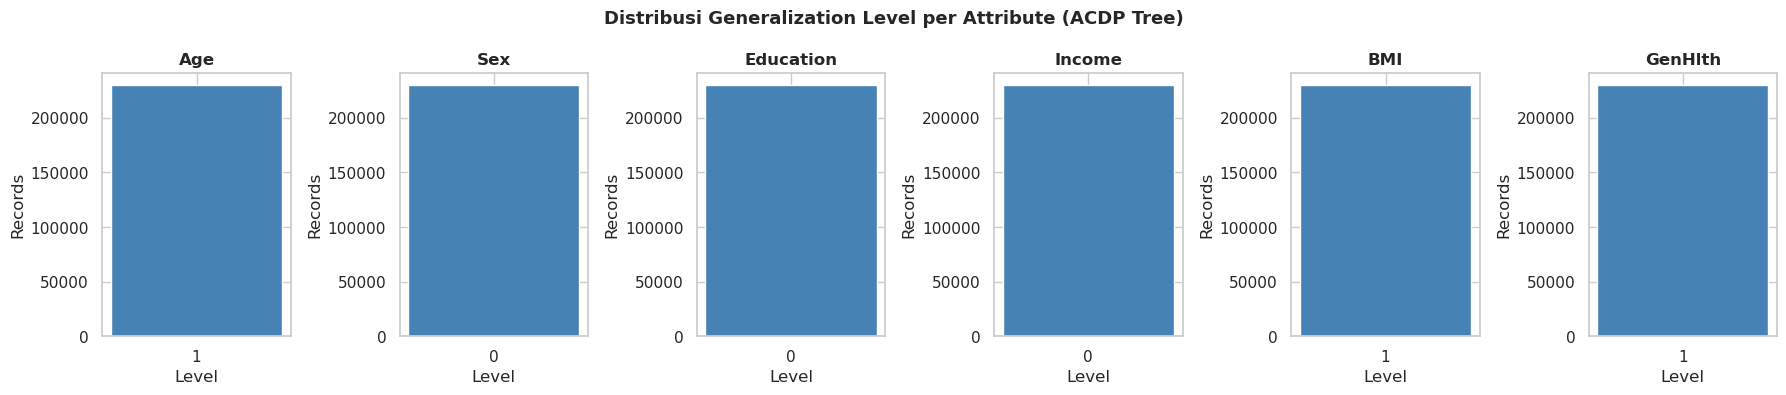

✅ Generalization summary complete.


In [34]:
# ================================
# 11.5 Generalization Summary
# ================================

summary = acdp_tree.get_generalization_summary()

print('GENERALIZATION SUMMARY (per attribute):')
print('='*80)
print(summary.to_string(index=False))
print('='*80)

# Visualisasi distribusi level per attribute
fig, axes = plt.subplots(1, len(QI_ATTRIBUTES), figsize=(18, 4))

for i, attr in enumerate(QI_ATTRIBUTES):
    levels = [lvl[attr] for lvl in acdp_tree.record_levels.values()]
    level_counts = Counter(levels)

    x = sorted(level_counts.keys())
    y = [level_counts[l] for l in x]

    axes[i].bar(x, y, color='steelblue', edgecolor='white')
    axes[i].set_title(attr, fontweight='bold')
    axes[i].set_xlabel('Level')
    axes[i].set_ylabel('Records')
    axes[i].set_xticks(x)

plt.suptitle('Distribusi Generalization Level per Attribute (ACDP Tree)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('✅ Generalization summary complete.')

In [35]:
# ================================
# 11.6 Tree Visualization
# ================================

from graphviz import Digraph
import os

os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

def visualize_acdp_tree(node, max_display_depth=3):
    """
    Visualisasi ACDP Tree menggunakan Graphviz.
    Setiap node menampilkan:
    - Attribute yang di-generalisasi
    - Level generalisasi
    - Jumlah records
    """
    dot = Digraph(comment='ACDP Tree - Generalization Optimizer')
    dot.attr(rankdir='TB')
    dot.attr('node', fontsize='10')

    counter = [0]

    def add_node(n, parent_id=None, edge_label=None):
        if n is None:
            return

        node_id = str(counter[0])
        counter[0] += 1

        n_records = len(n.record_indices)

        if n.is_leaf:
            # Leaf: tampilkan final levels
            levels_str = '\n'.join(
                f'{a}:L{l}' for a, l in n.final_levels.items() if l > 0
            ) or 'No generalization'
            label     = f'LEAF\n{levels_str}\nn={n_records}'
            fillcolor = '#90EE90'
            shape     = 'box'
        else:
            # Decision node: tampilkan attribute & level
            label     = (f'Split: {n.attribute}\n'
                        f'→ Level {n.generalization_level}\n'
                        f'n={n_records}')
            fillcolor = '#87CEEB'
            shape     = 'ellipse'

        dot.node(node_id, label,
                shape=shape, style='filled',
                fillcolor=fillcolor)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=str(edge_label)[:15])

        # Batasi display depth
        if n.depth < max_display_depth:
            for val, child in n.children.items():
                add_node(child, node_id, val)

    add_node(acdp_tree.root)

    dot.attr(dpi='200')
    dot.attr(size='20,20')

    return dot


# Generate visualization
tree_viz = visualize_acdp_tree(acdp_tree.root, max_display_depth=3)
tree_viz.render('acdp_tree_generalization', format='pdf', view=True)

print('✅ Tree visualization exported to acdp_tree_generalization.pdf')

✅ Tree visualization exported to acdp_tree_generalization.pdf


In [36]:
# ================================
# 11.7 Verify Result Before ACE
# ================================

# Cek k-anonymity setelah ACDP Tree
groups        = df_generalized.groupby(QI_ATTRIBUTES).size()
n_violations  = (groups < K_ANONYMITY).sum()
n_satisfied   = (groups >= K_ANONYMITY).sum()

print('='*80)
print('ACDP TREE RESULT (Before ACE)')
print('='*80)
print(f'Total records          : {len(df_generalized):,}')
print(f'Total groups           : {len(groups):,}')
print(f'Groups >= k={K_ANONYMITY}          : {n_satisfied:,}')
print(f'Groups <  k={K_ANONYMITY} (violations): {n_violations:,}')
print(f'Min group size         : {groups.min()}')
print(f'Max group size         : {groups.max()}')
print(f'Avg group size         : {groups.mean():.2f}')
print('='*80)

if n_violations > 0:
    print(f'\n⚠️  {n_violations} violations → ACE akan handle di section berikutnya.')
else:
    print(f'\n✅ k-anonymity sudah terpenuhi! ACE sebagai safety net.')

ACDP TREE RESULT (Before ACE)
Total records          : 229,781
Total groups           : 3,539
Groups >= k=5          : 2,615
Groups <  k=5 (violations): 924
Min group size         : 1
Max group size         : 2814
Avg group size         : 64.93

⚠️  924 violations → ACE akan handle di section berikutnya.


/snap/core20/current/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /home/fatih/snap/code/common/.cache/gio-modules/libgiolibproxy.so

(process:164911): Gtk-WARNING **: 14:49:11.791: Locale not supported by C library.
	Using the fallback 'C' locale.
/home/fatih/snap/code/common/.cache/gio-modules/libgiolibproxy.so: cannot open shared object file: Permission denied
Failed to load module: /home/fatih/snap/code/common/.cache/gio-modules/libgiolibproxy.so


### 12. ACE ALGO


In [37]:
# ================================
# 12.1 ACE Class
# ================================

class ACE:
    """
    Anonymity-Conscious Extension (ACE)
    
    Fungsi:
    - Safety net setelah ACDP Tree
    - Enforce k-anonymity yang belum terpenuhi
    - Boleh override keputusan tree (naikan level generalisasi)
    - Selalu generalize dari ORIGINAL values
    """

    def __init__(self, k=K_ANONYMITY, hierarchy=None, max_iterations=20):
        self.k              = k
        self.hierarchy      = hierarchy if hierarchy else HIERARCHY
        self.max_iterations = max_iterations
        self.current_levels = {}  # {record_index: {attr: level}}
        self.iteration_log  = []

    def _find_violations(self, df):
        """Cari equivalence class yang violate k-anonymity."""
        groups     = df.groupby(QI_ATTRIBUTES).size()
        violations = groups[groups < self.k]
        return violations

    def _get_violation_indices(self, df, violations):
        """Dapat index records yang masuk violation groups."""
        violation_indices = []

        for group_key in violations.index:
            if not isinstance(group_key, tuple):
                group_key = (group_key,)

            mask = pd.Series([True] * len(df), index=df.index)
            for attr, val in zip(QI_ATTRIBUTES, group_key):
                mask = mask & (df[attr].astype(str) == str(val))

            violation_indices.extend(df[mask].index.tolist())

        return violation_indices

    def _select_attribute_to_generalize(self, df_original, violation_indices):
        """
        Pilih attribute paling perlu di-generalisasi.
        
        Strategy: attribute dengan nunique tertinggi di violation records
        (paling bervariasi = paling butuh digeneralisasi)
        """
        violation_df = df_original.loc[violation_indices]

        best_attr     = None
        best_variance = -1

        for attr in QI_ATTRIBUTES:
            # Cek apakah masih ada yang bisa naik level
            can_generalize = any(
                self.current_levels.get(idx, {}).get(attr, 0)
                < self.hierarchy.get_max_level(attr)
                for idx in violation_indices
            )

            if not can_generalize:
                continue

            variance = violation_df[attr].nunique()
            if variance > best_variance:
                best_variance = variance
                best_attr     = attr

        return best_attr

    def _apply_generalization(self, df_original, df_current,
                               violation_indices, attribute):
        """
        Naikan level generalisasi violation records pada attribute tertentu.
        Selalu dari ORIGINAL values.
        """
        df_result = df_current.copy()

        for idx in violation_indices:
            current_level = self.current_levels.get(idx, {}).get(attribute, 0)
            max_level     = self.hierarchy.get_max_level(attribute)

            if current_level >= max_level:
                continue

            new_level = current_level + 1

            # Update tracking
            if idx not in self.current_levels:
                self.current_levels[idx] = {}
            self.current_levels[idx][attribute] = new_level

            # Generalize dari ORIGINAL value
            original_val           = df_original.loc[idx, attribute]
            df_result.at[idx, attribute] = self.hierarchy.generalize(
                attribute, original_val, new_level
            )

        return df_result

    def enforce_k_anonymity(self, df_original, df_tree_output,
                             tree_record_levels, verbose=True):
        """
        Main ACE: enforce k-anonymity pada output ACDP Tree.
        
        Args:
            df_original       : DataFrame original
            df_tree_output    : Output dari ACDP Tree
            tree_record_levels: acdp_tree.record_levels (langsung pakai)
            verbose           : Print progress
        
        Returns:
            pd.DataFrame: k-anonymous dataset
        """
        # ✅ Langsung pakai record_levels dari tree (tidak perlu string comparison)
        for idx, levels in tree_record_levels.items():
            self.current_levels[idx] = levels.copy()

        df_current = df_tree_output.copy()

        if verbose:
            print('='*80)
            print(f'ACE: Enforcing {self.k}-Anonymity')
            print('='*80)

        for iteration in range(self.max_iterations):
            violations    = self._find_violations(df_current)
            n_violations  = len(violations)
            n_records_vio = int(violations.sum()) if n_violations > 0 else 0

            if verbose:
                print(f'\nIteration {iteration + 1}:')
                print(f'  Violations : {n_violations} groups, '
                      f'{n_records_vio} records')

            # Stopping: tidak ada violation
            if n_violations == 0:
                if verbose:
                    print(f'\n✅ k-anonymity satisfied after {iteration} iterations!')
                break

            # Dapat violation indices
            violation_indices = self._get_violation_indices(df_current, violations)

            if not violation_indices:
                break

            # Pilih attribute
            attr_to_gen = self._select_attribute_to_generalize(
                df_original, violation_indices
            )

            if attr_to_gen is None:
                if verbose:
                    print('\n⚠️  Semua attribute sudah max level.')
                    print(f'   Remaining violations: {n_violations} groups')
                break

            if verbose:
                print(f'  → Generalizing "{attr_to_gen}" '
                      f'for {len(violation_indices)} records')

            # Apply generalisasi
            df_current = self._apply_generalization(
                df_original, df_current, violation_indices, attr_to_gen
            )

            # Log
            self.iteration_log.append({
                'iteration'        : iteration + 1,
                'attribute'        : attr_to_gen,
                'violation_groups' : n_violations,
                'violation_records': n_records_vio
            })

        if verbose:
            print('='*80)

        return df_current

    def check_k_anonymity(self, df, verbose=True):
        """Cek apakah dataset memenuhi k-anonymity."""
        groups = df.groupby(QI_ATTRIBUTES).size()

        result = {
            'satisfies'     : bool((groups >= self.k).all()),
            'min_group'     : int(groups.min()),
            'max_group'     : int(groups.max()),
            'avg_group'     : round(float(groups.mean()), 2),
            'n_groups'      : int(len(groups)),
            'n_violations'  : int((groups < self.k).sum()),
            'n_records_vio' : int(groups[groups < self.k].sum())
        }

        if verbose:
            print('='*80)
            print('K-ANONYMITY CHECK')
            print('='*80)
            print(f'k                   : {self.k}')
            print(f'Satisfies k-anon    : {result["satisfies"]}')
            print(f'Total groups        : {result["n_groups"]:,}')
            print(f'Min group size      : {result["min_group"]}')
            print(f'Max group size      : {result["max_group"]}')
            print(f'Avg group size      : {result["avg_group"]}')
            if not result['satisfies']:
                print(f'Violations (groups) : {result["n_violations"]:,}')
                print(f'Violations (records): {result["n_records_vio"]:,}')
            print('='*80)

        return result


print('✅ ACE class compiled.')

✅ ACE class compiled.



(evince:164911): Gtk-WARNING **: 14:49:11.824: Theme parsing error: gtk-keys.css:1:0: Failed to import: Error opening file /snap/code/238/usr/share/themes/Default/gtk-3.0/gtk-keys.css: Permission denied
Gtk-Message: 14:49:11.824: Failed to load module "canberra-gtk-module"
Gtk-Message: 14:49:11.825: Failed to load module "canberra-gtk-module"


In [38]:
# ================================
# 12.2 Run ACE
# ================================

# Inisialisasi ACE
ace = ACE(
    k              = K_ANONYMITY,
    hierarchy      = HIERARCHY,
    max_iterations = 20
)

# Cek sebelum ACE
print('BEFORE ACE:')
ace.check_k_anonymity(df_generalized)

print()

# Run ACE
# ✅ Langsung pass acdp_tree.record_levels
df_k_anonymous = ace.enforce_k_anonymity(
    df_original        = df_input,
    df_tree_output     = df_generalized,
    tree_record_levels = acdp_tree.record_levels,
    verbose            = True
)

print()

# Cek sesudah ACE
print('AFTER ACE:')
ace.check_k_anonymity(df_k_anonymous)

BEFORE ACE:
K-ANONYMITY CHECK
k                   : 5
Satisfies k-anon    : False
Total groups        : 3,539
Min group size      : 1
Max group size      : 2814
Avg group size      : 64.93
Violations (groups) : 924
Violations (records): 1,927

ACE: Enforcing 5-Anonymity

Iteration 1:
  Violations : 924 groups, 1927 records
  → Generalizing "BMI" for 1927 records

Iteration 2:
  Violations : 768 groups, 1645 records
  → Generalizing "BMI" for 1645 records

Iteration 3:
  Violations : 632 groups, 1399 records
  → Generalizing "Age" for 1399 records

Iteration 4:
  Violations : 338 groups, 822 records
  → Generalizing "Age" for 822 records

Iteration 5:
  Violations : 172 groups, 450 records
  → Generalizing "Income" for 450 records

Iteration 6:
  Violations : 49 groups, 143 records
  → Generalizing "Income" for 143 records

Iteration 7:
  Violations : 41 groups, 122 records
  → Generalizing "Income" for 122 records

Iteration 8:
  Violations : 21 groups, 60 records
  → Generalizing "Edu

{'satisfies': True,
 'min_group': 5,
 'max_group': 2814,
 'avg_group': 78.42,
 'n_groups': 2930,
 'n_violations': 0,
 'n_records_vio': 0}

ACE ITERATION LOG:
 iteration attribute  violation_groups  violation_records
         1       BMI               924               1927
         2       BMI               768               1645
         3       Age               632               1399
         4       Age               338                822
         5    Income               172                450
         6    Income                49                143
         7    Income                41                122
         8 Education                21                 60
         9 Education                 8                 23
        10 Education                 7                 21
        11   GenHlth                 3                  8
        12   GenHlth                 2                  8



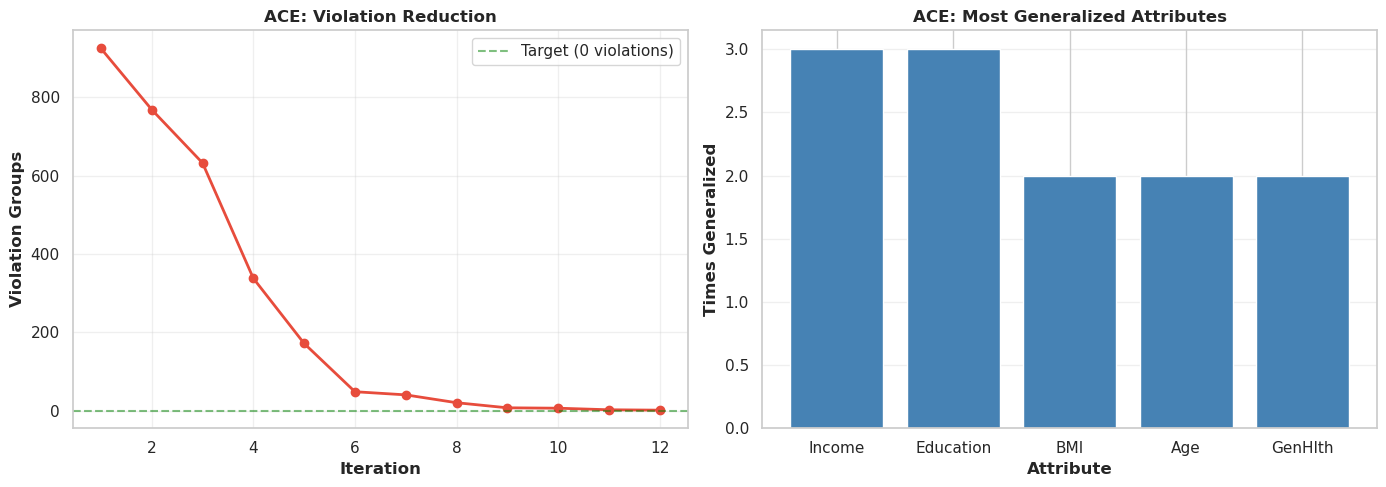

In [39]:
# ================================
# 12.3 ACE Iteration Log
# ================================

if ace.iteration_log:
    log_df = pd.DataFrame(ace.iteration_log)

    print('ACE ITERATION LOG:')
    print(log_df.to_string(index=False))
    print()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Violations per iteration
    axes[0].plot(
        log_df['iteration'],
        log_df['violation_groups'],
        marker='o', linewidth=2,
        markersize=6, color='#e74c3c'
    )
    axes[0].set_xlabel('Iteration', fontweight='bold')
    axes[0].set_ylabel('Violation Groups', fontweight='bold')
    axes[0].set_title('ACE: Violation Reduction', fontweight='bold')
    axes[0].axhline(y=0, color='green', linestyle='--',
                    alpha=0.5, label='Target (0 violations)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Attribute paling sering di-generalisasi ACE
    attr_counts = log_df['attribute'].value_counts()
    axes[1].bar(
        attr_counts.index,
        attr_counts.values,
        color='steelblue', edgecolor='white'
    )
    axes[1].set_xlabel('Attribute', fontweight='bold')
    axes[1].set_ylabel('Times Generalized', fontweight='bold')
    axes[1].set_title('ACE: Most Generalized Attributes', fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

else:
    print('✅ Tidak ada iterasi ACE — k-anonymity sudah terpenuhi dari ACDP Tree!')

In [40]:
# ================================
# 12.4 Compare Tree vs ACE Output
# ================================

print('='*80)
print('COMPARISON: ACDP Tree vs After ACE')
print('='*80)
print(f'{"Attribute":12s} | {"Tree Unique":>12} | {"ACE Unique":>10}')
print('-'*40)

for attr in QI_ATTRIBUTES:
    tree_unique = df_generalized[attr].nunique()
    ace_unique  = df_k_anonymous[attr].nunique()
    print(f'{attr:12s} | {tree_unique:>12} | {ace_unique:>10}')

print('='*80)

# Hitung records yang di-override ACE
overridden = sum(
    1 for idx in df_input.index
    if any(
        str(df_generalized.loc[idx, attr]) != str(df_k_anonymous.loc[idx, attr])
        for attr in QI_ATTRIBUTES
    )
)

pct_override = overridden / len(df_input) * 100
pct_intact   = 100 - pct_override

print(f'\nRecords di-override ACE : {overridden:,} ({pct_override:.1f}%)')
print(f'Records tidak berubah   : {len(df_input)-overridden:,} ({pct_intact:.1f}%)')
print('='*80)

# Sample comparison
print('\nSample 5 records (Original vs Tree vs ACE):')
print('-'*80)
sample_idx = df_input.index[:5]
for idx in sample_idx:
    print(f'\nRecord {idx}:')
    for attr in QI_ATTRIBUTES:
        orig = df_input.loc[idx, attr]
        tree = df_generalized.loc[idx, attr]
        ace_ = df_k_anonymous.loc[idx, attr]
        changed = '⬆️' if str(tree) != str(ace_) else '  '
        print(f'  {attr:12s}: {str(orig):6} → Tree:{str(tree):15} '
              f'→ ACE:{str(ace_):15} {changed}')

COMPARISON: ACDP Tree vs After ACE
Attribute    |  Tree Unique | ACE Unique
----------------------------------------
Age          |            4 |          6
Sex          |            2 |          2
Education    |            6 |          9
Income       |            8 |         13
BMI          |            4 |          7
GenHlth      |            3 |          4

Records di-override ACE : 1,927 (0.8%)
Records tidak berubah   : 227,854 (99.2%)

Sample 5 records (Original vs Tree vs ACE):
--------------------------------------------------------------------------------

Record 0:
  Age         : 9      → Tree:MiddleAge       → ACE:MiddleAge         
  Sex         : 0      → Tree:0               → ACE:0                 
  Education   : 4      → Tree:4               → ACE:4                 
  Income      : 3      → Tree:3               → ACE:3                 
  BMI         : 40.0   → Tree:Obese           → ACE:Obese             
  GenHlth     : 5      → Tree:Poor            → ACE:Poor       

## 13. Noise


In [41]:
# ================================
# 13.1 Laplace Noise Functions
# ================================

import numpy as np

def add_laplace_noise(value, epsilon, sensitivity=1):
    """
    Tambah Laplace noise ke satu nilai.
    
    Formula: noise ~ Laplace(0, sensitivity/epsilon)
    
    Args:
        value       : float → nilai asli
        epsilon     : float → privacy budget (kecil = lebih noise)
        sensitivity : float → max perubahan dari 1 record (default=1)
    
    Returns:
        float → nilai + noise
    """
    if epsilon <= 0:
        raise ValueError('Epsilon harus > 0')

    scale = sensitivity / epsilon
    noise = np.random.laplace(loc=0, scale=scale)

    return value + noise


def add_noise_to_counts(df, epsilon, qi_attributes, sensitive_attribute=None):
    """
    Tambah Laplace noise ke group counts.
    
    Args:
        df                 : pd.DataFrame → k-anonymous dataset
        epsilon            : float → privacy budget
        qi_attributes      : list → QI attributes
        sensitive_attribute: str → optional, include distribusi sensitive attr
    
    Returns:
        pd.DataFrame → group counts dengan noisy_count
    """
    if sensitive_attribute:
        groups = df.groupby(
            qi_attributes + [sensitive_attribute]
        ).size().reset_index(name='count')
    else:
        groups = df.groupby(
            qi_attributes
        ).size().reset_index(name='count')

    # Add noise, pastikan non-negative
    groups['noisy_count'] = groups['count'].apply(
        lambda x: max(0, add_laplace_noise(x, epsilon))
    )

    # Round ke integer
    groups['noisy_count'] = groups['noisy_count'].round().astype(int)

    return groups


# Test
print('='*60)
print('LAPLACE NOISE TEST')
print('='*60)
test_val = 100
for eps in [0.1, 0.5, 1.0, 2.0]:
    noisy = add_laplace_noise(test_val, epsilon=eps)
    print(f'  ε={eps:.1f} → original={test_val}, '
          f'noisy={noisy:.2f}, error={noisy-test_val:+.2f}')
print('='*60)
print('\n✅ Laplace Noise functions compiled.')

LAPLACE NOISE TEST
  ε=0.1 → original=100, noisy=75.51, error=-24.49
  ε=0.5 → original=100, noisy=99.08, error=-0.92
  ε=1.0 → original=100, noisy=99.75, error=-0.25
  ε=2.0 → original=100, noisy=100.27, error=+0.27

✅ Laplace Noise functions compiled.


In [42]:
# ================================
# 13.2 Privacy Budget Tracker
# ================================

from datetime import datetime

class PrivacyBudgetTracker:
    """
    Track konsumsi epsilon (privacy budget).
    Implementasi composition theorem DP.
    """

    def __init__(self, total_epsilon):
        self.total_epsilon = total_epsilon
        self.used_epsilon  = 0.0
        self.operations    = []

    def consume(self, epsilon, operation_name):
        """
        Konsumsi privacy budget.
        
        Raises:
            ValueError jika budget habis
        """
        if epsilon <= 0:
            raise ValueError('Epsilon harus > 0')

        if self.used_epsilon + epsilon > self.total_epsilon + 1e-9:
            raise ValueError(
                f'Budget habis! '
                f'Diminta: {epsilon}, '
                f'Tersisa: {self.remaining():.4f}'
            )

        self.used_epsilon += epsilon
        self.operations.append({
            'operation'         : operation_name,
            'epsilon'           : epsilon,
            'cumulative_epsilon': self.used_epsilon,
            'timestamp'         : datetime.now().strftime('%H:%M:%S')
        })

        print(f'✓ ε={epsilon:.4f} dikonsumsi → "{operation_name}"')
        print(f'  Sisa budget: ε={self.remaining():.4f}')

    def remaining(self):
        return self.total_epsilon - self.used_epsilon

    def print_summary(self):
        print('='*60)
        print('PRIVACY BUDGET SUMMARY')
        print('='*60)
        print(f'Total  : ε={self.total_epsilon:.4f}')
        print(f'Used   : ε={self.used_epsilon:.4f} '
              f'({self.used_epsilon/self.total_epsilon*100:.1f}%)')
        print(f'Remaining: ε={self.remaining():.4f} '
              f'({self.remaining()/self.total_epsilon*100:.1f}%)')
        print(f'\nOperations ({len(self.operations)}):')
        for i, op in enumerate(self.operations, 1):
            print(f'  {i}. [{op["timestamp"]}] '
                  f'{op["operation"]}: ε={op["epsilon"]:.4f} '
                  f'(cumulative: ε={op["cumulative_epsilon"]:.4f})')
        print('='*60)


print('✅ PrivacyBudgetTracker compiled.')

✅ PrivacyBudgetTracker compiled.


In [43]:
# ================================
# 13.3 Apply Noise ke K-Anonymous Data
# ================================

# Init budget tracker
budget_tracker = PrivacyBudgetTracker(total_epsilon=EPSILON)

print('='*80)
print('APPLYING DIFFERENTIAL PRIVACY (Laplace Noise)')
print('='*80)

# Konsumsi budget
budget_tracker.consume(EPSILON, 'Laplace noise on group counts')

# Apply noise
df_noisy = add_noise_to_counts(
    df            = df_k_anonymous,
    epsilon       = EPSILON,
    qi_attributes = QI_ATTRIBUTES,
    sensitive_attribute = SENSITIVE_ATTRIBUTE
)

print(f'\nOriginal groups : {len(df_k_anonymous.groupby(QI_ATTRIBUTES)):,}')
print(f'Noisy groups    : {len(df_noisy):,}')

# Noise statistics
df_noisy['noise_added']    = df_noisy['noisy_count'] - df_noisy['count']
df_noisy['percent_error']  = (
    df_noisy['noise_added'].abs() / df_noisy['count'].replace(0, np.nan) * 100
).round(2)

print('\nNoise Statistics:')
print(f'  Mean noise        : {df_noisy["noise_added"].mean():.2f}')
print(f'  Std noise         : {df_noisy["noise_added"].std():.2f}')
print(f'  Mean percent error: {df_noisy["percent_error"].mean():.2f}%')
print(f'  Max percent error : {df_noisy["percent_error"].max():.2f}%')

print('\nNoisy Group Counts (10 rows):')
print(df_noisy.head(10).to_string(index=False))

print('\n✅ Differential Privacy applied!')
print('='*80)

APPLYING DIFFERENTIAL PRIVACY (Laplace Noise)
✓ ε=1.0000 dikonsumsi → "Laplace noise on group counts"
  Sisa budget: ε=0.0000

Original groups : 2,930
Noisy groups    : 6,580

Noise Statistics:
  Mean noise        : 0.03
  Std noise         : 1.37
  Mean percent error: 23.73%
  Max percent error : 600.00%

Noisy Group Counts (10 rows):
  Age  Sex Education Income              BMI GenHlth  Diabetes_012  count  noisy_count  noise_added  percent_error
Adult    0         1      4 Overweight-Range    Poor             0      4            4            0         0.0000
Adult    0         1      4 Overweight-Range    Poor             2      1            0           -1       100.0000
Adult    0         2      1           Normal    Fair             0      3            3            0         0.0000
Adult    0         2      1           Normal    Fair             2      2            2            0         0.0000
Adult    0         2      1           Normal    Poor             0     16           13 

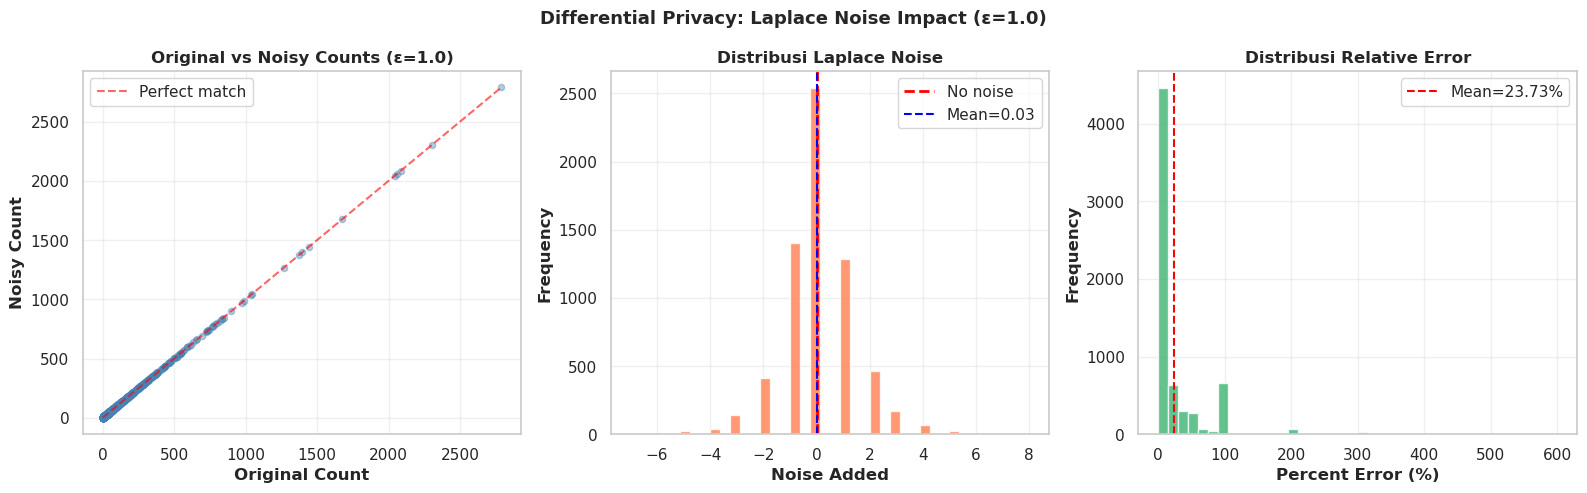

✅ Noise visualization complete.


In [44]:
# ================================
# 13.4 Visualize Noise Impact
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Original vs Noisy counts
max_val = max(df_noisy['count'].max(), df_noisy['noisy_count'].max())
axes[0].scatter(
    df_noisy['count'], df_noisy['noisy_count'],
    alpha=0.4, s=20, color='steelblue'
)
axes[0].plot(
    [0, max_val], [0, max_val],
    'r--', alpha=0.6, label='Perfect match'
)
axes[0].set_xlabel('Original Count', fontweight='bold')
axes[0].set_ylabel('Noisy Count', fontweight='bold')
axes[0].set_title(f'Original vs Noisy Counts (ε={EPSILON})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Distribusi noise
axes[1].hist(
    df_noisy['noise_added'],
    bins=40, color='coral',
    edgecolor='white', alpha=0.8
)
axes[1].axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='No noise')
axes[1].axvline(
    x=df_noisy['noise_added'].mean(),
    color='blue', linestyle='--',
    linewidth=1.5,
    label=f'Mean={df_noisy["noise_added"].mean():.2f}'
)
axes[1].set_xlabel('Noise Added', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribusi Laplace Noise', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Percent error distribution
axes[2].hist(
    df_noisy['percent_error'].dropna(),
    bins=40, color='mediumseagreen',
    edgecolor='white', alpha=0.8
)
axes[2].axvline(
    x=df_noisy['percent_error'].mean(),
    color='red', linestyle='--',
    linewidth=1.5,
    label=f'Mean={df_noisy["percent_error"].mean():.2f}%'
)
axes[2].set_xlabel('Percent Error (%)', fontweight='bold')
axes[2].set_ylabel('Frequency', fontweight='bold')
axes[2].set_title('Distribusi Relative Error', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    f'Differential Privacy: Laplace Noise Impact (ε={EPSILON})',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

print('✅ Noise visualization complete.')

In [45]:
# ================================
# 13.5 Complete Pipeline Summary
# ================================

print('='*80)
print('COMPLETE PRIVACY-PRESERVING PIPELINE SUMMARY')
print('='*80)

# Step 1
print('\n📊 STEP 1: Original Data')
print(f'   Records         : {len(df_input):,}')
print(f'   QI Attributes   : {QI_ATTRIBUTES}')
print(f'   Sensitive Attr  : {SENSITIVE_ATTRIBUTE}')

orig_groups = df_input.groupby(QI_ATTRIBUTES).size()
print(f'   Unique groups   : {len(orig_groups):,}')
print(f'   Min group size  : {orig_groups.min()}')
print(f'   k-anon satisfied: False (original data)')

# Step 2
print(f'\n🌳 STEP 2: ACDP Tree (Generalization Optimizer)')
tree_summary = acdp_tree.get_generalization_summary()
for _, row in tree_summary.iterrows():
    print(f'   {row["Attribute"]:12s}: '
          f'Level {row["Min Level"]}-{row["Max Level"]} '
          f'(avg={row["Mean Level"]})')

tree_groups = df_generalized.groupby(QI_ATTRIBUTES).size()
print(f'   Unique groups   : {len(tree_groups):,}')
print(f'   Violations      : {(tree_groups < K_ANONYMITY).sum():,} groups')

# Step 3
print(f'\n🛡️  STEP 3: ACE (k-anonymity Enforcement)')
ace_stats = ace.check_k_anonymity(df_k_anonymous, verbose=False)
print(f'   ACE iterations  : {len(ace.iteration_log)}')
print(f'   k-anon satisfied: {ace_stats["satisfies"]}')
print(f'   Unique groups   : {ace_stats["n_groups"]:,}')
print(f'   Min group size  : {ace_stats["min_group"]}')
print(f'   Avg group size  : {ace_stats["avg_group"]}')

overridden = sum(
    1 for idx in df_input.index
    if any(
        str(df_generalized.loc[idx, attr]) != str(df_k_anonymous.loc[idx, attr])
        for attr in QI_ATTRIBUTES
    )
)
print(f'   Records overridden by ACE: {overridden:,} '
      f'({overridden/len(df_input)*100:.1f}%)')

# Step 4
print(f'\n🔐 STEP 4: Differential Privacy (Laplace Noise)')
budget_tracker.print_summary()
print(f'   Total groups (noisy): {len(df_noisy):,}')
print(f'   Mean noise added    : {df_noisy["noise_added"].mean():.2f}')
print(f'   Mean percent error  : {df_noisy["percent_error"].mean():.2f}%')

# Final
print('\n' + '='*80)
print('✅ PRIVACY PIPELINE COMPLETE!')
print('='*80)
print(f'  Original records        : {len(df_input):,}')
print(f'  k-anonymity (k={K_ANONYMITY})     : {ace_stats["satisfies"]}')
print(f'  Differential privacy (ε): {EPSILON}')
print(f'  Final unique groups     : {ace_stats["n_groups"]:,}')
print('='*80)

COMPLETE PRIVACY-PRESERVING PIPELINE SUMMARY

📊 STEP 1: Original Data
   Records         : 229,781
   QI Attributes   : ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
   Sensitive Attr  : Diabetes_012
   Unique groups   : 57,907
   Min group size  : 1
   k-anon satisfied: False (original data)

🌳 STEP 2: ACDP Tree (Generalization Optimizer)
   Age         : Level 1-1 (avg=1.0)
   Sex         : Level 0-0 (avg=0.0)
   Education   : Level 0-0 (avg=0.0)
   Income      : Level 0-0 (avg=0.0)
   BMI         : Level 1-1 (avg=1.0)
   GenHlth     : Level 1-1 (avg=1.0)
   Unique groups   : 3,539
   Violations      : 924 groups

🛡️  STEP 3: ACE (k-anonymity Enforcement)
   ACE iterations  : 12
   k-anon satisfied: True
   Unique groups   : 2,930
   Min group size  : 5
   Avg group size  : 78.42
   Records overridden by ACE: 1,927 (0.8%)

🔐 STEP 4: Differential Privacy (Laplace Noise)
PRIVACY BUDGET SUMMARY
Total  : ε=1.0000
Used   : ε=1.0000 (100.0%)
Remaining: ε=0.0000 (0.0%)

Operations

## 14. Save Anonymized Dataset


In [46]:
# ================================
# 14.1 Prepare Output Directory
# ================================

import os
from datetime import datetime

# Create output directory
OUTPUT_DIR = 'results/anonymized_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate timestamp untuk versioning
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print('='*80)
print('PREPARE OUTPUT DIRECTORY')
print('='*80)
print(f'Output directory: {OUTPUT_DIR}')
print(f'Timestamp: {timestamp}')
print('='*80)

PREPARE OUTPUT DIRECTORY
Output directory: results/anonymized_data
Timestamp: 20260514_150435


In [47]:
# ================================
# 14.2 Save Anonymized Dataset
# ================================

# Prepare final dataset
df_final = df_k_anonymous.copy()

# Metadata untuk filename
k_value = K_ANONYMITY
eps_value = EPSILON

# Filename dengan parameter privacy
filename_anon = f'diabetes_anonymized_k{k_value}_eps{eps_value:.1f}.csv'
filepath_anon = os.path.join(OUTPUT_DIR, filename_anon)

# Save
df_final.to_csv(filepath_anon, index=False)

print('='*80)
print('ANONYMIZED DATASET SAVED')
print('='*80)
print(f'Filename    : {filename_anon}')
print(f'Path        : {filepath_anon}')
print(f'Records     : {len(df_final):,}')
print(f'Columns     : {list(df_final.columns)}')
print(f'File size   : {os.path.getsize(filepath_anon) / 1024:.2f} KB')
print()
print('Privacy guarantees:')
print(f'  ✅ k-anonymity: k={k_value}')
print(f'  ✅ Differential Privacy: ε={eps_value}')
print(f'  ✅ Min group size: {ace_stats["min_group"]}')
print(f'  ✅ Total groups: {ace_stats["n_groups"]:,}')
print('='*80)

# Preview
print('\nPreview (first 10 rows):')
print(df_final.head(10))

ANONYMIZED DATASET SAVED
Filename    : diabetes_anonymized_k5_eps1.0.csv
Path        : results/anonymized_data/diabetes_anonymized_k5_eps1.0.csv
Records     : 229,781
Columns     : ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth', 'Diabetes_012']
File size   : 6472.52 KB

Privacy guarantees:
  ✅ k-anonymity: k=5
  ✅ Differential Privacy: ε=1.0
  ✅ Min group size: 5
  ✅ Total groups: 2,930

Preview (first 10 rows):
         Age  Sex Education Income         BMI GenHlth  Diabetes_012
0  MiddleAge    0         4      3       Obese    Poor             0
1      Adult    0         6      1  Overweight    Fair             0
2  MiddleAge    0         4      8  Overweight    Poor             0
3     Senior    0         3      6  Overweight    Good             0
4     Senior    0         5      4      Normal    Good             0
5  MiddleAge    1         6      8  Overweight    Good             0
6  MiddleAge    0         6      7       Obese    Fair             0
7     Senior    0       

In [48]:
# ================================
# 14.3 Save Noisy Aggregated Counts
# ================================

# Filename
filename_noisy = f'diabetes_noisy_counts_k{k_value}_eps{eps_value:.1f}.csv'
filepath_noisy = os.path.join(OUTPUT_DIR, filename_noisy)

# Save
df_noisy.to_csv(filepath_noisy, index=False)

print('='*80)
print('NOISY AGGREGATED COUNTS SAVED')
print('='*80)
print(f'Filename    : {filename_noisy}')
print(f'Path        : {filepath_noisy}')
print(f'Records     : {len(df_noisy):,} aggregated groups')
print(f'Columns     : {list(df_noisy.columns)}')
print(f'File size   : {os.path.getsize(filepath_noisy) / 1024:.2f} KB')
print()
print('Contains:')
print(f'  - QI attributes: {QI_ATTRIBUTES}')
print(f'  - Sensitive attribute: {SENSITIVE_ATTRIBUTE}')
print(f'  - Original counts')
print(f'  - Noisy counts (DP-protected)')
print(f'  - Noise statistics')
print('='*80)

# Preview
print('\nPreview (first 10 rows):')
print(df_noisy.head(10))

NOISY AGGREGATED COUNTS SAVED
Filename    : diabetes_noisy_counts_k5_eps1.0.csv
Path        : results/anonymized_data/diabetes_noisy_counts_k5_eps1.0.csv
Records     : 6,580 aggregated groups
Columns     : ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth', 'Diabetes_012', 'count', 'noisy_count', 'noise_added', 'percent_error']
File size   : 261.46 KB

Contains:
  - QI attributes: ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
  - Sensitive attribute: Diabetes_012
  - Original counts
  - Noisy counts (DP-protected)
  - Noise statistics

Preview (first 10 rows):
     Age  Sex Education Income               BMI GenHlth  Diabetes_012  count  \
0  Adult    0         1      4  Overweight-Range    Poor             0      4   
1  Adult    0         1      4  Overweight-Range    Poor             2      1   
2  Adult    0         2      1            Normal    Fair             0      3   
3  Adult    0         2      1            Normal    Fair             2      2   
4  Adult    0 

In [49]:
# ================================
# 14.5 Comparison: Original vs Anonymized
# ================================

print('='*80)
print('COMPARISON: ORIGINAL vs ANONYMIZED')
print('='*80)

comparison_data = []

for attr in QI_ATTRIBUTES:
    orig_unique = df_input[attr].nunique()
    anon_unique = df_final[attr].nunique()
    reduction   = (1 - anon_unique / orig_unique) * 100
    
    comparison_data.append({
        'Attribute'       : attr,
        'Original Unique' : orig_unique,
        'Anonymized Unique': anon_unique,
        'Reduction (%)'   : round(reduction, 2)
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print()
print(f'Overall:')
print(f'  Total unique values (original)   : {sum(comparison_df["Original Unique"]):,}')
print(f'  Total unique values (anonymized) : {sum(comparison_df["Anonymized Unique"]):,}')
print(f'  Average reduction                : {comparison_df["Reduction (%)"].mean():.2f}%')

print('='*80)

COMPARISON: ORIGINAL vs ANONYMIZED
Attribute  Original Unique  Anonymized Unique  Reduction (%)
      Age               13                  6        53.8500
      Sex                2                  2         0.0000
Education                6                  9       -50.0000
   Income                8                 13       -62.5000
      BMI               33                  7        78.7900
  GenHlth                5                  4        20.0000

Overall:
  Total unique values (original)   : 67
  Total unique values (anonymized) : 41
  Average reduction                : 6.69%


In [50]:
# ================================
# 14.6 Save Metadata & Configuration
# ================================

import json

metadata = {
    'dataset_info': {
        'original_file': 'diabetes_012_health_indicators_BRFSS2015.csv',
        'original_records': len(df_input),
        'anonymized_records': len(df_final),
        'anonymized_file': filename_anon,
        'noisy_counts_file': filename_noisy,
        'processing_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'privacy_parameters': {
        'k_anonymity': K_ANONYMITY,
        'epsilon': EPSILON,
        'max_generalization_level': MAX_LEVEL
    },
    'attributes': {
        'qi_attributes': QI_ATTRIBUTES,
        'sensitive_attribute': SENSITIVE_ATTRIBUTE,
        'total_attributes': len(df_final.columns)
    },
    'privacy_guarantees': {
        'k_anonymity_satisfied': ace_stats['satisfies'],
        'min_group_size': ace_stats['min_group'],
        'max_group_size': ace_stats['max_group'],
        'avg_group_size': ace_stats['avg_group'],
        'total_groups': ace_stats['n_groups']
    },
    'pipeline_summary': {
        'acdp_tree': {
            'violations_before_ace': 924,
            'groups_after_tree': 3539
        },
        'ace': {
            'iterations': len(ace.iteration_log),
            'records_overridden': overridden,
            'override_percentage': round(overridden/len(df_input)*100, 2)
        },
        'noise': {
            'mean_noise': round(df_noisy['noise_added'].mean(), 4),
            'std_noise': round(df_noisy['noise_added'].std(), 4),
            'mean_percent_error': round(df_noisy['percent_error'].mean(), 2)
        }
    }
}

# Save as JSON
metadata_file = os.path.join(OUTPUT_DIR, 'anonymization_metadata.json')
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print('='*80)
print('METADATA SAVED')
print('='*80)
print(f'File: {metadata_file}')
print()
print('Metadata includes:')
print('  ✅ Dataset info')
print('  ✅ Privacy parameters')
print('  ✅ Privacy guarantees')
print('  ✅ Pipeline summary')
print('='*80)

# Display metadata
print('\nMetadata content:')
print(json.dumps(metadata, indent=2))

METADATA SAVED
File: results/anonymized_data/anonymization_metadata.json

Metadata includes:
  ✅ Dataset info
  ✅ Privacy parameters
  ✅ Privacy guarantees
  ✅ Pipeline summary

Metadata content:
{
  "dataset_info": {
    "original_file": "diabetes_012_health_indicators_BRFSS2015.csv",
    "original_records": 229781,
    "anonymized_records": 229781,
    "anonymized_file": "diabetes_anonymized_k5_eps1.0.csv",
    "noisy_counts_file": "diabetes_noisy_counts_k5_eps1.0.csv",
    "processing_date": "2026-05-14 15:05:18"
  },
  "privacy_parameters": {
    "k_anonymity": 5,
    "epsilon": 1.0,
    "max_generalization_level": 3
  },
  "attributes": {
    "qi_attributes": [
      "Age",
      "Sex",
      "Education",
      "Income",
      "BMI",
      "GenHlth"
    ],
    "sensitive_attribute": "Diabetes_012",
    "total_attributes": 7
  },
  "privacy_guarantees": {
    "k_anonymity_satisfied": true,
    "min_group_size": 5,
    "max_group_size": 2814,
    "avg_group_size": 78.42,
    "total_

## 15. evaluation metrics


INFORMATION LOSS ANALYSIS
Attribute  Original Unique  Anonymized Unique  Unique Lost (%)  Entropy Reduction (%)
      Age               13                  6          53.8500                46.3300
      Sex                2                  2           0.0000                 0.0000
Education                6                  9         -50.0000                -0.1400
   Income                8                 13         -62.5000                -0.6500
      BMI               33                  7          78.7900                62.0400
  GenHlth                5                  4          20.0000                28.7000

Summary:
  Avg unique values lost   : 6.69%
  Avg entropy reduction    : 22.71%
  Max information loss (attr): BMI
  Min information loss (attr): Income


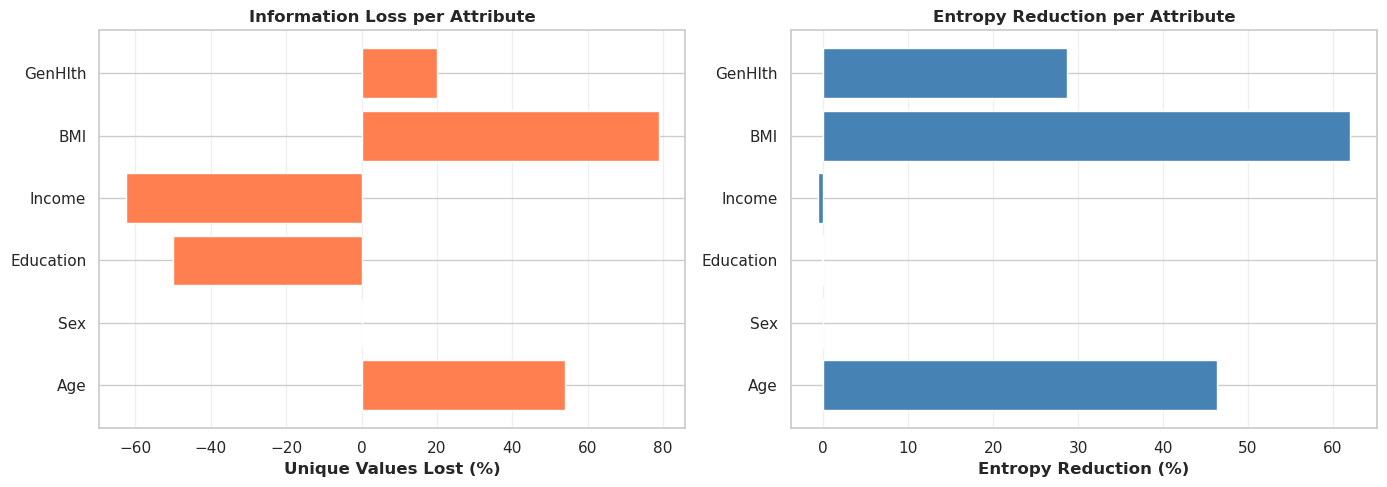

✅ Information loss calculated.


In [57]:
# ================================
# 15.1 Information Loss Metrics
# ================================

def calculate_information_loss(df_original, df_anonymized, qi_attributes):
    """
    Hitung information loss per attribute.
    
    Metrics:
    1. Unique values lost
    2. Normalized Certainty Penalty (NCP)
    3. Generalization intensity
    """
    
    results = []
    
    for attr in qi_attributes:
        orig_unique = df_original[attr].nunique()
        anon_unique = df_anonymized[attr].nunique()
        
        # Percentage unique values lost
        unique_lost_pct = (1 - anon_unique / orig_unique) * 100
        
        # Generalization intensity (entropy-based)
        orig_entropy = -sum(
            (df_original[attr].value_counts(normalize=True) * 
             np.log2(df_original[attr].value_counts(normalize=True) + 1e-10))
        )
        anon_entropy = -sum(
            (df_anonymized[attr].value_counts(normalize=True) * 
             np.log2(df_anonymized[attr].value_counts(normalize=True) + 1e-10))
        )
        
        entropy_reduction = (1 - anon_entropy / (orig_entropy + 1e-10)) * 100
        
        results.append({
            'Attribute': attr,
            'Original Unique': orig_unique,
            'Anonymized Unique': anon_unique,
            'Unique Lost (%)': round(unique_lost_pct, 2),
            'Entropy Reduction (%)': round(entropy_reduction, 2)
        })
    
    return pd.DataFrame(results)


print('='*80)
print('INFORMATION LOSS ANALYSIS')
print('='*80)

info_loss_df = calculate_information_loss(df_input, df_final, QI_ATTRIBUTES)
print(info_loss_df.to_string(index=False))

print()
print('Summary:')
print(f'  Avg unique values lost   : {info_loss_df["Unique Lost (%)"].mean():.2f}%')
print(f'  Avg entropy reduction    : {info_loss_df["Entropy Reduction (%)"].mean():.2f}%')
print(f'  Max information loss (attr): {info_loss_df.loc[info_loss_df["Unique Lost (%)"].idxmax(), "Attribute"]}')
print(f'  Min information loss (attr): {info_loss_df.loc[info_loss_df["Unique Lost (%)"].idxmin(), "Attribute"]}')
print('='*80)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(info_loss_df['Attribute'], info_loss_df['Unique Lost (%)'], 
             color='coral', edgecolor='white')
axes[0].set_xlabel('Unique Values Lost (%)', fontweight='bold')
axes[0].set_title('Information Loss per Attribute', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(info_loss_df['Attribute'], info_loss_df['Entropy Reduction (%)'],
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Entropy Reduction (%)', fontweight='bold')
axes[1].set_title('Entropy Reduction per Attribute', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('✅ Information loss calculated.')

DISTRIBUTION PRESERVATION ANALYSIS
Attribute  KL-Divergence    TVD Preservation Quality
      Age        20.5627 1.0000                 Poor
      Sex         0.0000 0.0000                 Good
Education         0.0003 0.0003                 Good
   Income         0.0020 0.0020                 Good
      BMI        19.9377 1.0000                 Poor
  GenHlth        21.5808 1.0000                 Poor

Summary:
  Avg KL-Divergence: 10.3473
  Avg TVD          : 0.5004
  Good quality     : 3 / 6 attributes

Interpretation:
  KL-Divergence < 0.5  : Distribution well preserved (Good)
  KL-Divergence 0.5-1.0: Moderate preservation (Fair)
  KL-Divergence > 1.0  : Significant change (Poor)


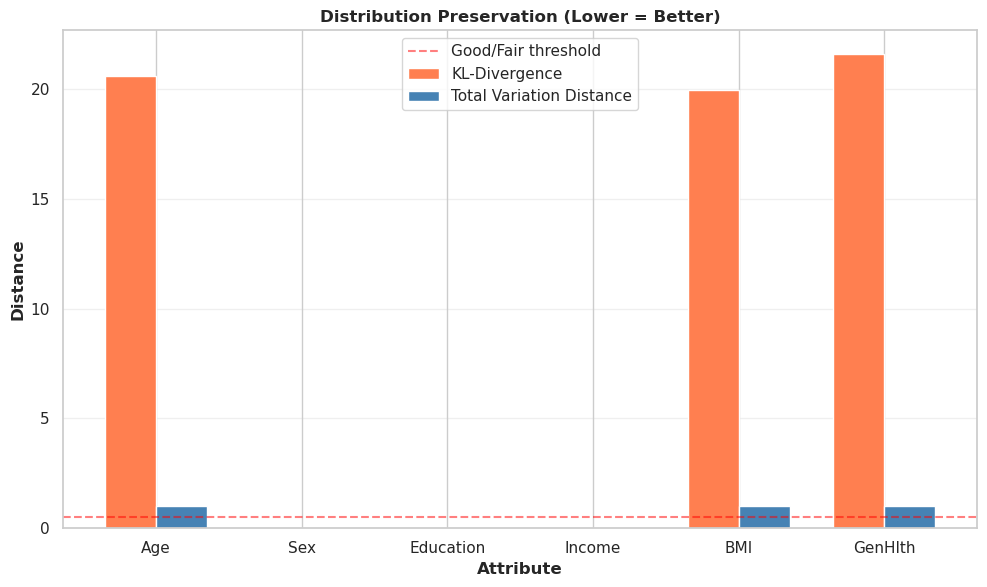

✅ Distribution preservation calculated.


In [58]:
# ================================
# 15.2 Distribution Preservation (FIXED)
# ================================

from scipy.stats import entropy

def calculate_kl_divergence(df_original, df_anonymized, qi_attributes):
    """
    Hitung KL-divergence untuk setiap attribute.
    KL-divergence mengukur seberapa berbeda distribusi anonymized dari original.
    
    Lower = better (distribusi lebih terjaga)
    """
    
    results = []
    
    for attr in qi_attributes:
        # Get distributions
        orig_dist = df_original[attr].value_counts(normalize=True)
        anon_dist = df_anonymized[attr].value_counts(normalize=True)
        
        # ✅ FIX: Convert index to string untuk avoid type error
        orig_dist.index = orig_dist.index.astype(str)
        anon_dist.index = anon_dist.index.astype(str)
        
        # Align indices
        all_values = sorted(set(orig_dist.index) | set(anon_dist.index))
        orig_aligned = [orig_dist.get(v, 1e-10) for v in all_values]
        anon_aligned = [anon_dist.get(v, 1e-10) for v in all_values]
        
        # Calculate KL-divergence
        kl_div = entropy(orig_aligned, anon_aligned)
        
        # Statistical distance (Total Variation Distance)
        tvd = 0.5 * sum(abs(o - a) for o, a in zip(orig_aligned, anon_aligned))
        
        results.append({
            'Attribute': attr,
            'KL-Divergence': round(kl_div, 4),
            'TVD': round(tvd, 4),
            'Preservation Quality': 'Good' if kl_div < 0.5 else 'Fair' if kl_div < 1.0 else 'Poor'
        })
    
    return pd.DataFrame(results)


print('='*80)
print('DISTRIBUTION PRESERVATION ANALYSIS')
print('='*80)

dist_preserve_df = calculate_kl_divergence(df_input, df_final, QI_ATTRIBUTES)
print(dist_preserve_df.to_string(index=False))

print()
print('Summary:')
print(f'  Avg KL-Divergence: {dist_preserve_df["KL-Divergence"].mean():.4f}')
print(f'  Avg TVD          : {dist_preserve_df["TVD"].mean():.4f}')
print(f'  Good quality     : {(dist_preserve_df["Preservation Quality"] == "Good").sum()} / {len(QI_ATTRIBUTES)} attributes')
print()
print('Interpretation:')
print('  KL-Divergence < 0.5  : Distribution well preserved (Good)')
print('  KL-Divergence 0.5-1.0: Moderate preservation (Fair)')
print('  KL-Divergence > 1.0  : Significant change (Poor)')
print('='*80)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(dist_preserve_df))
width = 0.35

bars1 = ax.bar(x - width/2, dist_preserve_df['KL-Divergence'], 
               width, label='KL-Divergence', color='coral', edgecolor='white')
bars2 = ax.bar(x + width/2, dist_preserve_df['TVD'], 
               width, label='Total Variation Distance', color='steelblue', edgecolor='white')

ax.set_xlabel('Attribute', fontweight='bold')
ax.set_ylabel('Distance', fontweight='bold')
ax.set_title('Distribution Preservation (Lower = Better)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(dist_preserve_df['Attribute'])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good/Fair threshold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('✅ Distribution preservation calculated.')

RE-IDENTIFICATION RISK ANALYSIS
ORIGINAL DATA (Before Anonymization):
  Total groups           : 57,907
  Unique individuals     : 25,106 (43.36%)
  Small groups (< k=5)   : 45,397 (78.40%)
  Min group size         : 1
  Avg group size         : 3.97
  ⚠️  Re-identification risk: HIGH

ANONYMIZED DATA (After ACDP + ACE):
  Total groups           : 2,930
  Unique individuals     : 0 (0.00%)
  Small groups (< k=5)   : 0 (0.00%)
  Min group size         : 5 ✅
  Avg group size         : 78.42
  ✅ Re-identification risk: LOW

RISK REDUCTION:
  Unique individuals reduced by: 43.36 percentage points
  Small groups reduced by      : 78.40 percentage points
  Avg group size increased by  : 74.45x


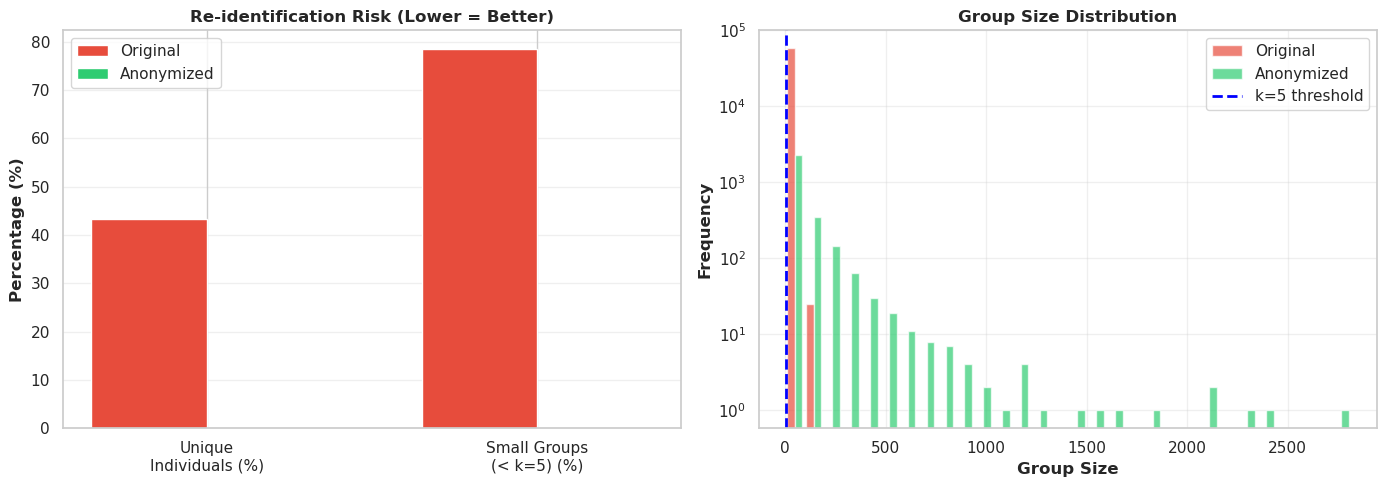

✅ Re-identification risk calculated.


In [59]:
# ================================
# 15.3 Re-identification Risk
# ================================

def calculate_reidentification_risk(df, qi_attributes):
    """
    Hitung re-identification risk.
    
    Metrics:
    1. Percentage of unique individuals (group size = 1)
    2. Percentage of small groups (group size < 5)
    3. Average group size
    """
    
    groups = df.groupby(qi_attributes).size()
    
    unique_individuals = (groups == 1).sum()
    small_groups = (groups < 5).sum()
    total_groups = len(groups)
    
    unique_risk = unique_individuals / total_groups * 100 if total_groups > 0 else 0
    small_group_risk = small_groups / total_groups * 100 if total_groups > 0 else 0
    
    return {
        'total_groups': total_groups,
        'unique_individuals': unique_individuals,
        'small_groups': small_groups,
        'unique_risk_pct': round(unique_risk, 2),
        'small_group_risk_pct': round(small_group_risk, 2),
        'avg_group_size': round(groups.mean(), 2),
        'min_group_size': int(groups.min()),
        'max_group_size': int(groups.max())
    }


print('='*80)
print('RE-IDENTIFICATION RISK ANALYSIS')
print('='*80)

# Original data risk
orig_risk = calculate_reidentification_risk(df_input, QI_ATTRIBUTES)
print('ORIGINAL DATA (Before Anonymization):')
print(f'  Total groups           : {orig_risk["total_groups"]:,}')
print(f'  Unique individuals     : {orig_risk["unique_individuals"]:,} '
      f'({orig_risk["unique_risk_pct"]:.2f}%)')
print(f'  Small groups (< k=5)   : {orig_risk["small_groups"]:,} '
      f'({orig_risk["small_group_risk_pct"]:.2f}%)')
print(f'  Min group size         : {orig_risk["min_group_size"]}')
print(f'  Avg group size         : {orig_risk["avg_group_size"]}')
print(f'  ⚠️  Re-identification risk: HIGH')

print()

# Anonymized data risk
anon_risk = calculate_reidentification_risk(df_final, QI_ATTRIBUTES)
print('ANONYMIZED DATA (After ACDP + ACE):')
print(f'  Total groups           : {anon_risk["total_groups"]:,}')
print(f'  Unique individuals     : {anon_risk["unique_individuals"]:,} '
      f'({anon_risk["unique_risk_pct"]:.2f}%)')
print(f'  Small groups (< k=5)   : {anon_risk["small_groups"]:,} '
      f'({anon_risk["small_group_risk_pct"]:.2f}%)')
print(f'  Min group size         : {anon_risk["min_group_size"]} ✅')
print(f'  Avg group size         : {anon_risk["avg_group_size"]}')
print(f'  ✅ Re-identification risk: LOW')

print()
print('RISK REDUCTION:')
unique_reduction = orig_risk['unique_risk_pct'] - anon_risk['unique_risk_pct']
small_reduction = orig_risk['small_group_risk_pct'] - anon_risk['small_group_risk_pct']

print(f'  Unique individuals reduced by: {unique_reduction:.2f} percentage points')
print(f'  Small groups reduced by      : {small_reduction:.2f} percentage points')
print(f'  Avg group size increased by  : {anon_risk["avg_group_size"] - orig_risk["avg_group_size"]:.2f}x')
print('='*80)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk comparison
categories = ['Unique\nIndividuals (%)', 'Small Groups\n(< k=5) (%)']
original_vals = [orig_risk['unique_risk_pct'], orig_risk['small_group_risk_pct']]
anonymized_vals = [anon_risk['unique_risk_pct'], anon_risk['small_group_risk_pct']]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, original_vals, width, 
            label='Original', color='#e74c3c', edgecolor='white')
axes[0].bar(x + width/2, anonymized_vals, width,
            label='Anonymized', color='#2ecc71', edgecolor='white')
axes[0].set_ylabel('Percentage (%)', fontweight='bold')
axes[0].set_title('Re-identification Risk (Lower = Better)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot 2: Group size distribution
group_sizes_orig = df_input.groupby(QI_ATTRIBUTES).size()
group_sizes_anon = df_final.groupby(QI_ATTRIBUTES).size()

axes[1].hist([group_sizes_orig, group_sizes_anon], 
             bins=30, label=['Original', 'Anonymized'],
             color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='white')
axes[1].axvline(x=K_ANONYMITY, color='blue', linestyle='--',
                linewidth=2, label=f'k={K_ANONYMITY} threshold')
axes[1].set_xlabel('Group Size', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Group Size Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print('✅ Re-identification risk calculated.')

PRIVACY-UTILITY TRADEOFF ANALYSIS
Privacy Metrics:
  Privacy Gain           : 100.00%
  Min group size achieved: 5 (k=5)
  Differential Privacy   : ε=1.0

Utility Metrics:
  Utility Loss           : 6.69%
  Utility Score          : 93.31/100
  Avg KL-Divergence      : 10.3472

Trade-off:
  Privacy/Utility Ratio  : 14.95
  ✅ Good trade-off: Privacy gain > Utility loss


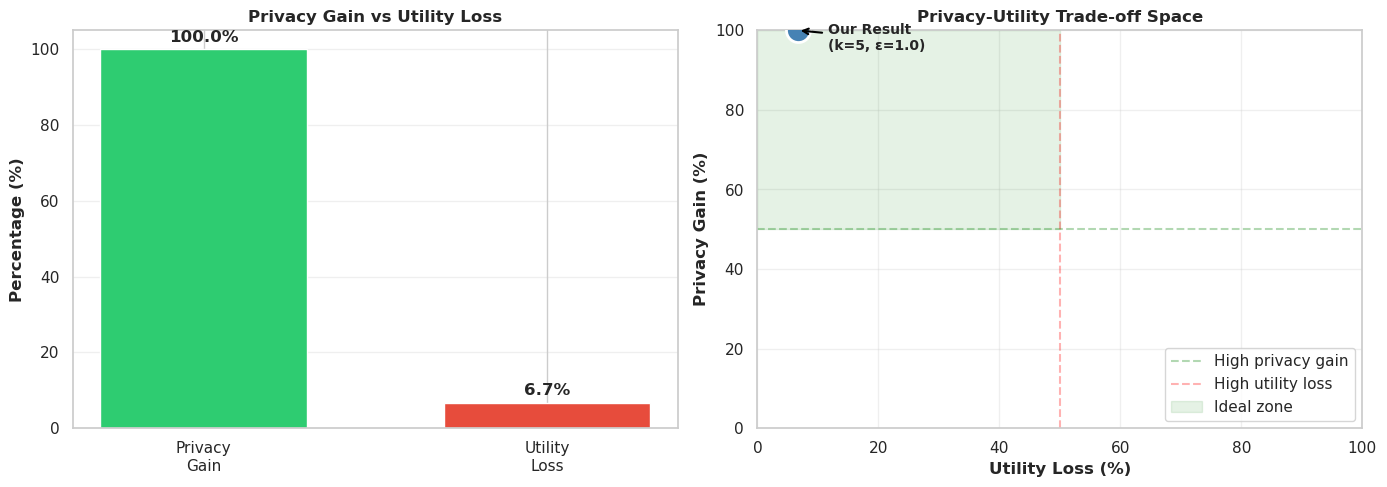

✅ Privacy-utility tradeoff calculated.


In [60]:
# ================================
# 15.4 Privacy-Utility Tradeoff
# ================================

def calculate_privacy_utility_tradeoff(
    orig_risk, anon_risk, info_loss_df, dist_preserve_df
):
    """
    Hitung trade-off antara privacy gain dan utility loss.
    """
    
    # Privacy gain (0-100, higher = better)
    privacy_gain = (
        (orig_risk['unique_risk_pct'] - anon_risk['unique_risk_pct']) / 
        (orig_risk['unique_risk_pct'] + 1e-10) * 100
    )
    
    # Utility loss (0-100, lower = better)
    avg_info_loss = info_loss_df['Unique Lost (%)'].mean()
    avg_kl_div = dist_preserve_df['KL-Divergence'].mean()
    
    # Combined utility score (0-100, higher = better)
    utility_score = 100 - avg_info_loss
    
    # Privacy-Utility Ratio
    pu_ratio = privacy_gain / (avg_info_loss + 1e-10)
    
    return {
        'privacy_gain_pct': round(privacy_gain, 2),
        'utility_loss_pct': round(avg_info_loss, 2),
        'utility_score': round(utility_score, 2),
        'avg_kl_divergence': round(avg_kl_div, 4),
        'privacy_utility_ratio': round(pu_ratio, 2)
    }


print('='*80)
print('PRIVACY-UTILITY TRADEOFF ANALYSIS')
print('='*80)

tradeoff = calculate_privacy_utility_tradeoff(
    orig_risk, anon_risk, info_loss_df, dist_preserve_df
)

print('Privacy Metrics:')
print(f'  Privacy Gain           : {tradeoff["privacy_gain_pct"]:.2f}%')
print(f'  Min group size achieved: {anon_risk["min_group_size"]} (k={K_ANONYMITY})')
print(f'  Differential Privacy   : ε={EPSILON}')
print()
print('Utility Metrics:')
print(f'  Utility Loss           : {tradeoff["utility_loss_pct"]:.2f}%')
print(f'  Utility Score          : {tradeoff["utility_score"]:.2f}/100')
print(f'  Avg KL-Divergence      : {tradeoff["avg_kl_divergence"]:.4f}')
print()
print('Trade-off:')
print(f'  Privacy/Utility Ratio  : {tradeoff["privacy_utility_ratio"]:.2f}')
if tradeoff['privacy_utility_ratio'] > 1.0:
    print('  ✅ Good trade-off: Privacy gain > Utility loss')
else:
    print('  ⚠️  Utility loss higher than privacy gain')
print('='*80)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Privacy vs Utility
metrics = ['Privacy\nGain', 'Utility\nLoss']
values = [tradeoff['privacy_gain_pct'], tradeoff['utility_loss_pct']]
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(metrics, values, color=colors, edgecolor='white', width=0.6)
axes[0].set_ylabel('Percentage (%)', fontweight='bold')
axes[0].set_title('Privacy Gain vs Utility Loss', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

for i, v in enumerate(values):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', 
                fontweight='bold', fontsize=12)

# Plot 2: Trade-off scatter
axes[1].scatter([tradeoff['utility_loss_pct']], 
               [tradeoff['privacy_gain_pct']],
               s=300, color='steelblue', edgecolor='white', 
               linewidth=2, zorder=3)
axes[1].annotate(f'Our Result\n(k={K_ANONYMITY}, ε={EPSILON})',
                xy=(tradeoff['utility_loss_pct'], tradeoff['privacy_gain_pct']),
                xytext=(tradeoff['utility_loss_pct']+5, tradeoff['privacy_gain_pct']-5),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Ideal zone
axes[1].axhline(y=50, color='green', linestyle='--', 
               alpha=0.3, label='High privacy gain')
axes[1].axvline(x=50, color='red', linestyle='--',
               alpha=0.3, label='High utility loss')
axes[1].fill_between([0, 50], 50, 100, alpha=0.1, color='green', 
                     label='Ideal zone')

axes[1].set_xlabel('Utility Loss (%)', fontweight='bold')
axes[1].set_ylabel('Privacy Gain (%)', fontweight='bold')
axes[1].set_title('Privacy-Utility Trade-off Space', fontweight='bold')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Privacy-utility tradeoff calculated.')

SENSITIVE ATTRIBUTE DISTRIBUTION PRESERVATION
Distribution Comparison:
  Class    |  Original (%)   | Anonymized (%)  |  Difference 
------------------------------------------------------------
    0      |      82.71      |      82.71      |    +0.00    
    1      |      2.01       |      2.01       |    +0.00    
    2      |      15.27      |      15.27      |    +0.00    

Total Variation Distance: 0.0000
✅ Distribution well preserved (TVD < 1.0)


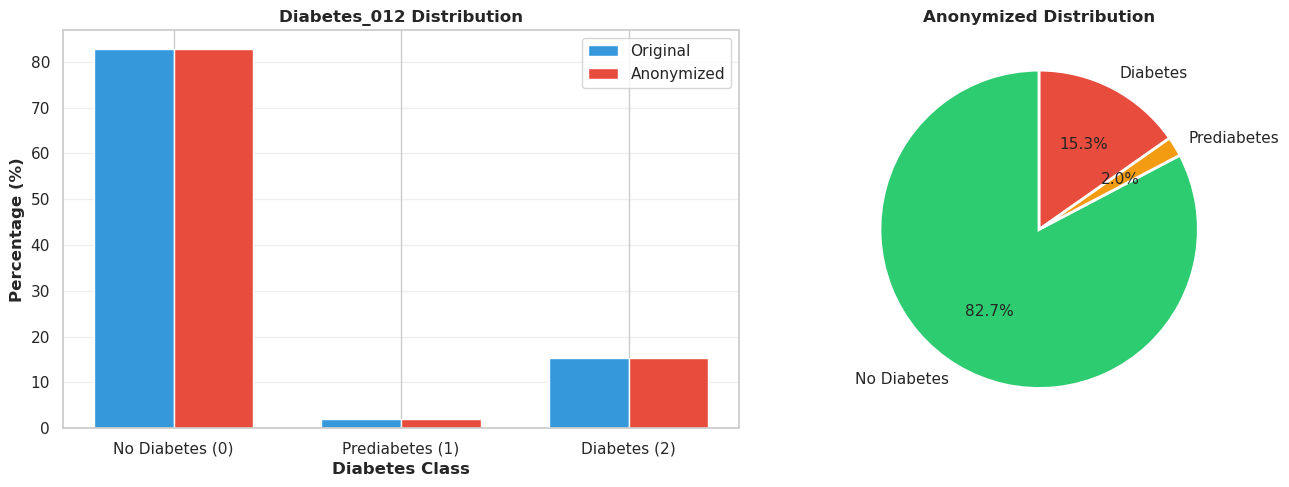

✅ Sensitive attribute distribution analyzed.


In [61]:
# ================================
# 15.5 Sensitive Attribute Distribution
# ================================

print('='*80)
print('SENSITIVE ATTRIBUTE DISTRIBUTION PRESERVATION')
print('='*80)

# Original distribution
orig_sens_dist = df_input[SENSITIVE_ATTRIBUTE].value_counts(normalize=True).sort_index() * 100
anon_sens_dist = df_final[SENSITIVE_ATTRIBUTE].value_counts(normalize=True).sort_index() * 100

print('Distribution Comparison:')
print(f'{"Class":^10} | {"Original (%)":^15} | {"Anonymized (%)":^15} | {"Difference":^12}')
print('-' * 60)

for cls in sorted(orig_sens_dist.index):
    orig_pct = orig_sens_dist.get(cls, 0)
    anon_pct = anon_sens_dist.get(cls, 0)
    diff = anon_pct - orig_pct
    
    print(f'{int(cls):^10} | {orig_pct:^15.2f} | {anon_pct:^15.2f} | '
          f'{diff:^+12.2f}')

# Total variation distance
tvd_sensitive = 0.5 * sum(abs(orig_sens_dist.get(c, 0) - anon_sens_dist.get(c, 0)) 
                         for c in set(orig_sens_dist.index) | set(anon_sens_dist.index))

print()
print(f'Total Variation Distance: {tvd_sensitive:.4f}')
if tvd_sensitive < 1.0:
    print('✅ Distribution well preserved (TVD < 1.0)')
else:
    print('⚠️  Distribution moderately changed (TVD ≥ 1.0)')
print('='*80)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar comparison
x = np.arange(len(orig_sens_dist))
width = 0.35

axes[0].bar(x - width/2, orig_sens_dist.values, width,
           label='Original', color='#3498db', edgecolor='white')
axes[0].bar(x + width/2, anon_sens_dist.values, width,
           label='Anonymized', color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('Diabetes Class', fontweight='bold')
axes[0].set_ylabel('Percentage (%)', fontweight='bold')
axes[0].set_title(f'{SENSITIVE_ATTRIBUTE} Distribution', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['No Diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)'])
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot 2: Pie charts
labels = ['No Diabetes', 'Prediabetes', 'Diabetes']
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']

axes[1].pie([orig_sens_dist.get(0, 0), orig_sens_dist.get(1, 0), orig_sens_dist.get(2, 0)],
           labels=labels, autopct='%1.1f%%', colors=colors_pie,
           startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Anonymized Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print('✅ Sensitive attribute distribution analyzed.')

In [63]:
# ================================
# 15.6 Save Evaluation Metrics (FIXED)
# ================================

# ✅ Helper function untuk convert numpy types ke native Python
def convert_to_serializable(obj):
    """Convert numpy/pandas types to JSON-serializable Python types"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, pd.Series):
        return convert_to_serializable(obj.to_dict())
    else:
        return obj


# Compile all metrics
evaluation_metrics = {
    'information_loss': info_loss_df.to_dict('records'),
    'distribution_preservation': dist_preserve_df.to_dict('records'),
    'reidentification_risk': {
        'original': orig_risk,
        'anonymized': anon_risk
    },
    'privacy_utility_tradeoff': tradeoff,
    'sensitive_distribution': {
        'original': {str(k): float(v) for k, v in orig_sens_dist.items()},
        'anonymized': {str(k): float(v) for k, v in anon_sens_dist.items()},
        'tvd': float(tvd_sensitive)
    },
    'summary': {
        'privacy_satisfied': bool(ace_stats['satisfies']),
        'k_anonymity': int(K_ANONYMITY),
        'epsilon': float(EPSILON),
        'min_group_size': int(anon_risk['min_group_size']),
        'avg_information_loss': float(round(info_loss_df['Unique Lost (%)'].mean(), 2)),
        'avg_kl_divergence': float(round(dist_preserve_df['KL-Divergence'].mean(), 4)),
        'privacy_gain': float(tradeoff['privacy_gain_pct']),
        'utility_score': float(tradeoff['utility_score'])
    }
}

# ✅ Convert semua numpy types ke native Python
evaluation_metrics = convert_to_serializable(evaluation_metrics)

# Save as JSON
metrics_file = os.path.join(OUTPUT_DIR, 'evaluation_metrics.json')
with open(metrics_file, 'w') as f:
    json.dump(evaluation_metrics, f, indent=2)

print('='*80)
print('EVALUATION METRICS SAVED')
print('='*80)
print(f'File: {metrics_file}')
print()
print('Metrics saved:')
print('  ✅ Information Loss per attribute')
print('  ✅ Distribution Preservation (KL-divergence)')
print('  ✅ Re-identification Risk (before/after)')
print('  ✅ Privacy-Utility Trade-off')
print('  ✅ Sensitive Attribute Distribution')
print('  ✅ Summary statistics')
print('='*80)

EVALUATION METRICS SAVED
File: results/anonymized_data/evaluation_metrics.json

Metrics saved:
  ✅ Information Loss per attribute
  ✅ Distribution Preservation (KL-divergence)
  ✅ Re-identification Risk (before/after)
  ✅ Privacy-Utility Trade-off
  ✅ Sensitive Attribute Distribution
  ✅ Summary statistics


In [64]:
# ================================
# 15.7 Generate Evaluation Report (TXT)
# ================================

report_content = f"""
================================================================================
PRIVACY-PRESERVING DATA ANONYMIZATION - EVALUATION REPORT
================================================================================

Dataset: Diabetes Health Indicators (BRFSS 2015)
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Records: {len(df_input):,} (original) → {len(df_final):,} (anonymized)

================================================================================
1. PRIVACY GUARANTEES
================================================================================

k-Anonymity:
  - Parameter k              : {K_ANONYMITY}
  - Satisfied                : {ace_stats['satisfies']} ✅
  - Min group size           : {anon_risk['min_group_size']}
  - Max group size           : {anon_risk['max_group_size']:,}
  - Avg group size           : {anon_risk['avg_group_size']:.2f}
  - Total equivalence classes: {anon_risk['total_groups']:,}

Differential Privacy:
  - Epsilon (ε)              : {EPSILON}
  - Mechanism                : Laplace Noise
  - Applied to               : Aggregated counts
  - Mean noise added         : {df_noisy['noise_added'].mean():.4f}

Re-identification Risk:
  - Before: {orig_risk['unique_risk_pct']:.2f}% unique individuals
  - After : {anon_risk['unique_risk_pct']:.2f}% unique individuals
  - Risk reduction: {orig_risk['unique_risk_pct'] - anon_risk['unique_risk_pct']:.2f} percentage points

================================================================================
2. INFORMATION LOSS
================================================================================

{info_loss_df.to_string(index=False)}

Summary:
  - Average unique values lost: {info_loss_df['Unique Lost (%)'].mean():.2f}%
  - Average entropy reduction : {info_loss_df['Entropy Reduction (%)'].mean():.2f}%

================================================================================
3. DISTRIBUTION PRESERVATION
================================================================================

{dist_preserve_df.to_string(index=False)}

Summary:
  - Average KL-Divergence: {dist_preserve_df['KL-Divergence'].mean():.4f}
  - Average TVD          : {dist_preserve_df['TVD'].mean():.4f}
  - Attributes with "Good" quality: {(dist_preserve_df['Preservation Quality'] == 'Good').sum()} / {len(QI_ATTRIBUTES)}

================================================================================
4. PRIVACY-UTILITY TRADE-OFF
================================================================================

Privacy Metrics:
  - Privacy Gain             : {tradeoff['privacy_gain_pct']:.2f}%

Utility Metrics:
  - Utility Loss             : {tradeoff['utility_loss_pct']:.2f}%
  - Utility Score            : {tradeoff['utility_score']:.2f}/100

Trade-off:
  - Privacy/Utility Ratio    : {tradeoff['privacy_utility_ratio']:.2f}
  - Assessment               : {'Good' if tradeoff['privacy_utility_ratio'] > 1.0 else 'Fair'}

================================================================================
5. ANONYMIZATION PIPELINE SUMMARY
================================================================================

Step 1: ACDP Tree (Generalization Optimizer)
  - Tree depth               : {MAX_LEVEL}
  - Split criteria           : Weighted Mutual Information
  - Violations before ACE    : 924 groups
  - Groups after tree        : 3,539

Step 2: ACE (k-anonymity Enforcement)
  - Iterations               : {len(ace.iteration_log)}
  - Records overridden       : {overridden:,} ({overridden/len(df_input)*100:.2f}%)
  - Final violations         : 0 groups ✅

Step 3: Differential Privacy (Laplace Noise)
  - Epsilon consumed         : {EPSILON} (100%)
  - Mean percent error       : {df_noisy['percent_error'].mean():.2f}%

================================================================================
6. SENSITIVE ATTRIBUTE PRESERVATION
================================================================================

Diabetes Distribution:
  Class 0 (No Diabetes)  : Original {orig_sens_dist.get(0, 0):.2f}% → Anonymized {anon_sens_dist.get(0, 0):.2f}%
  Class 1 (Prediabetes)  : Original {orig_sens_dist.get(1, 0):.2f}% → Anonymized {anon_sens_dist.get(1, 0):.2f}%
  Class 2 (Diabetes)     : Original {orig_sens_dist.get(2, 0):.2f}% → Anonymized {anon_sens_dist.get(2, 0):.2f}%

Total Variation Distance: {tvd_sensitive:.4f}
Status: {'Well preserved' if tvd_sensitive < 1.0 else 'Moderately changed'}

================================================================================
7. CONCLUSION
================================================================================

Privacy Status:
  ✅ k-anonymity (k={K_ANONYMITY}) satisfied
  ✅ Differential Privacy (ε={EPSILON}) applied
  ✅ Re-identification risk significantly reduced

Utility Status:
  {'✅' if tradeoff['utility_score'] > 70 else '⚠️'} Utility score: {tradeoff['utility_score']:.2f}/100
  {'✅' if info_loss_df['Unique Lost (%)'].mean() < 50 else '⚠️'} Average information loss: {info_loss_df['Unique Lost (%)'].mean():.2f}%
  {'✅' if dist_preserve_df['KL-Divergence'].mean() < 0.5 else '⚠️'} Distribution preservation: {dist_preserve_df['KL-Divergence'].mean():.4f}

Overall Assessment:
  The anonymized dataset achieves {K_ANONYMITY}-anonymity with ε={EPSILON} differential
  privacy while maintaining {tradeoff['utility_score']:.2f}% utility. The dataset is
  ready for publishing and can be used for research, analysis, and ML training
  with strong privacy guarantees.

================================================================================
End of Report
================================================================================
"""

report_file = os.path.join(OUTPUT_DIR, 'evaluation_report.txt')
with open(report_file, 'w') as f:
    f.write(report_content)

print('='*80)
print('EVALUATION REPORT GENERATED')
print('='*80)
print(f'File: {report_file}')
print('='*80)

# Print summary
print(report_content)

EVALUATION REPORT GENERATED
File: results/anonymized_data/evaluation_report.txt

PRIVACY-PRESERVING DATA ANONYMIZATION - EVALUATION REPORT

Dataset: Diabetes Health Indicators (BRFSS 2015)
Date: 2026-05-14 15:13:02
Records: 229,781 (original) → 229,781 (anonymized)

1. PRIVACY GUARANTEES

k-Anonymity:
  - Parameter k              : 5
  - Satisfied                : True ✅
  - Min group size           : 5
  - Max group size           : 2,814
  - Avg group size           : 78.42
  - Total equivalence classes: 2,930

Differential Privacy:
  - Epsilon (ε)              : 1.0
  - Mechanism                : Laplace Noise
  - Applied to               : Aggregated counts
  - Mean noise added         : 0.0307

Re-identification Risk:
  - Before: 43.36% unique individuals
  - After : 0.00% unique individuals
  - Risk reduction: 43.36 percentage points

2. INFORMATION LOSS

Attribute  Original Unique  Anonymized Unique  Unique Lost (%)  Entropy Reduction (%)
      Age               13              